<table width="100%" style="border:none; border-collapse:collapse;">
<tr style="border:none;">
<td width="150" style="border:none;"></td>
<td align="center" style="border:none;">
    <h1>Tarea Semanal 6</h1>
    <h2>Teoría de los Circuitos II - R4052</h2>
    <h3>Fabián Alexander Iturrizaga Meza</h3>
    <br>
    <b>Docentes</b><br>
    Profesor: Mariano Llamedo Soria<br>
    Jefe de TPs: César Fuoco<br>
    Ayudante de TPs: David Moharos
</td>
<td width="150" align="right" style="border:none; vertical-align:top;"><img src="./img/logo_UTN.svg" width="150" /></td>
</tr>
</table>

***

## Consigna

<div>
  <img src="./img/consigna_ts6_1.png" width="900" />
</div>
<div>
  <img src="./img/consigna_ts6_2.png" width="1500" />
</div>

In [9]:
import warnings
warnings.filterwarnings('ignore')

import sys
import os
import numpy as np
import sympy as sp
from scipy import signal as sig
import matplotlib.pyplot as plt

try:
    import pytc2
    print('pytc2 cargado desde instalación global')
except ImportError:
    sys.path.insert(0, os.path.abspath('../..'))
    import pytc2
    print('pytc2 cargado desde copia local')

print(f'Versión: {pytc2.__version__}')

from pytc2.cuadripolos import calc_MAI_vtransf_ij_mn
from pytc2.general import print_latex, print_subtitle, s, symbfunc2tf
from pytc2.sistemas_lineales import bodePlot

plt.rcParams['figure.figsize'] = [20, 8]
plt.rcParams['figure.dpi'] = 150
plt.rcParams.update({'font.size': 11})

pytc2 cargado desde instalación global
Versión: 0.2.1-local


<a id="p1"></a>

***

## Punto 1 — Comprobación de transferencia

Comprobar que el esquema se corresponde con la siguiente transferencia:

$$ H_{(z)} = (1 - c_1 \cdot z^{-N}) \cdot \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}} $$

### Resolución Analítica: Comprobación de la transferencia

Para analizar el diagrama en bloques, dividiremos el sistema en dos etapas conectadas en cascada: el filtro peine (Comb) y la red recursiva de segundo orden (Biquad).

Sea $w(n)$ la señal intermedia a la salida del sumador de la primera etapa, es decir, la entrada a la segunda etapa.

<div>
  <img src="./img/ejercicio_1_1.png" width="1000" />
</div>

#### 0. Resolución manuscrita

<div>
  <img src="./img/punto_1_1.jpg" width="900" />
</div>

#### 1. Análisis de la primera etapa (Comb filter)

Observando el primer bloque, la señal $w(n)$ se obtiene a partir de la entrada $x(n)$ y una versión retardada $N$ muestras y escalada por $c_1$. La ecuación en diferencias es:
$$ w(n) = x(n) - c_1 \cdot x(n-N) $$

Aplicando la Transformada Z a ambos miembros de la ecuación:
$$ W(z) = X(z) - c_1 \cdot z^{-N} X(z) $$

Factorizando $X(z)$, obtenemos la función de transferencia de la primera etapa $H_1(z)$:
$$ W(z) = X(z) \cdot (1 - c_1 \cdot z^{-N}) $$
$$ H_1(z) = \frac{W(z)}{X(z)} = 1 - c_1 \cdot z^{-N} $$

#### 2. Análisis de la segunda etapa (Biquad)

Para la red recursiva de 2do orden, definiremos la señal auxiliar $v(n)$ en el nodo central, **después del multiplicador $a_0$**. De este nodo es de donde la señal ingresa a los retardos $z^{-1}$ y al multiplicador $b_0$.

Si analizamos el sumador a la entrada del biquad, su salida debe ser la señal antes de multiplicarse por $a_0$. Por lo tanto, la salida de ese sumador es $\frac{v(n)}{a_0}$.
Las entradas que llegan a ese sumador son la señal $w(n)$ y las realimentaciones de $v(n)$ escaladas por $a_1$ y $a_2$. La ecuación en el sumador queda:

$$ \frac{v(n)}{a_0} = w(n) + a_1 \cdot v(n-1) + a_2 \cdot v(n-2) $$

Aplicando Transformada Z a esta expresión:
$$ \frac{V(z)}{a_0} = W(z) + a_1 \cdot z^{-1} V(z) + a_2 \cdot z^{-2} V(z) $$

Agrupando los términos con $V(z)$:
$$ V(z) \cdot \left( \frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2} \right) = W(z) $$
$$ V(z) = \frac{W(z)}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}} $$

Por otro lado, la salida $y(n)$ se forma sumando las ramas hacia adelante (feed-forward) que toman la señal $v(n)$ y sus versiones retardadas, multiplicadas por los coeficientes $b$:

$$ y(n) = b_0 \cdot v(n) + b_1 \cdot v(n-1) + b_2 \cdot v(n-2) $$

Aplicando Transformada Z a la salida:
$$ Y(z) = b_0 \cdot V(z) + b_1 \cdot z^{-1} V(z) + b_2 \cdot z^{-2} V(z) $$
$$ Y(z) = V(z) \cdot (b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}) $$

Sustituyendo la expresión de $V(z)$ hallada anteriormente:
$$ Y(z) = W(z) \cdot \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}} $$

Por lo tanto, la transferencia de la segunda etapa $H_2(z)$ es:
$$ H_2(z) = \frac{Y(z)}{W(z)} = \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}} $$

#### 3. Transferencia Total $H(z)$

Como las dos etapas están conectadas en cascada, la transferencia total es el producto de las transferencias individuales:
$$ H(z) = \frac{Y(z)}{X(z)} = H_1(z) \cdot H_2(z) $$

$$ H(z) = (1 - c_1 \cdot z^{-N}) \cdot \frac{b_0 + b_1 \cdot z^{-1} + b_2 \cdot z^{-2}}{\frac{1}{a_0} - a_1 \cdot z^{-1} - a_2 \cdot z^{-2}} $$

De esta forma queda comprobada la relación que describe el diagrama en bloques.

<a id="p2"></a>

***

## Punto 2 — Filtro de media móvil

Filtro de **media móvil** (*moving average* o CIC: *cascaded integrator-comb*):

* Verificar la transferencia para $a_0 = 1$, $a_1 = 1$, $b_0 = 1/N$, $c_1 = 1$ y $N = 3, 4$ y $5$.
* ¿Es un filtro IIR o FIR? Discuta las ventajas que tendría esta implementación respecto del filtro FIR de media móvil directo.
* ¿Podría implementar el sistema $h(k) = (1, 1, 1, 1, 1, 1, 1)$ con esta topología?

### Resolución analítica: filtro de media móvil (CIC)

#### 0. Resolución manuscrita

<div>
  <img src="./img/punto_2_1.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_2_2.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_2_3.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_2_4.jpg" width="500" />
</div>

#### 1. Sustitución de los coeficientes

Partimos de la transferencia general obtenida en el Punto 1:

$$
H(z)=(1-c_1z^{-N})
\frac{b_0+b_1z^{-1}+b_2z^{-2}}
{\frac{1}{a_0}-a_1z^{-1}-a_2z^{-2}}.
$$

Los coeficientes pedidos son

$$
a_0=1,\qquad a_1=1,\qquad a_2=0,
$$

$$
b_0=\frac{1}{N},\qquad b_1=b_2=0,\qquad c_1=1.
$$

Al reemplazarlos en la transferencia general:

$$
\begin{aligned}
H_N(z)
&=(1-z^{-N})
\frac{\frac{1}{N}}{1-z^{-1}}\\[4pt]
&=\boxed{\frac{1}{N}\frac{1-z^{-N}}{1-z^{-1}}}.
\end{aligned}
$$

A continuación se realiza la división de polinomios en $z^{-1}$. Equivalentemente, puede emplearse la identidad de la serie geométrica finita

$$
\frac{1-r^N}{1-r}=\sum_{k=0}^{N-1}r^k
=1+r+r^2+\cdots+r^{N-1}.
$$

Tomando $r=z^{-1}$ se obtiene

$$
\frac{1-z^{-N}}{1-z^{-1}}
=1+z^{-1}+z^{-2}+\cdots+z^{-(N-1)}
=\sum_{k=0}^{N-1}z^{-k}.
$$

Por lo tanto, la transferencia queda expresada como una suma finita:

$$
\boxed{
H_N(z)=\frac{1}{N}
\left(1+z^{-1}+z^{-2}+\cdots+z^{-(N-1)}\right)
=\frac{1}{N}\sum_{k=0}^{N-1}z^{-k}}.
$$

Como $H_N(z)=Y(z)/X(z)$,

$$
Y(z)=H_N(z)X(z)
=\frac{1}{N}\sum_{k=0}^{N-1}z^{-k}X(z).
$$

Para aplicar la antitransformada Z se utiliza la propiedad de desplazamiento temporal

$$
\mathcal{Z}^{-1}\left\{z^{-k}X(z)\right\}=x[n-k].
$$

Aplicando esta propiedad término a término se obtiene

$$
\boxed{
y[n]=\frac{1}{N}\sum_{k=0}^{N-1}x[n-k]
=\frac{1}{N}
\left(x[n]+x[n-1]+\cdots+x[n-(N-1)]\right)}.
$$

La salida es, por lo tanto, la media de la muestra actual y las $N-1$ muestras anteriores de la entrada. Esta expresión depende de una cantidad finita de muestras de $x[n]$, lo que muestra directamente que la transferencia entrada-salida es FIR de orden $N-1$.

La forma CIC antes de simplificar presenta un polo y un cero en $z=1$ que se cancelan exactamente. Para analizar el sistema se emplea la forma FIR reducida anterior; en ella, los $N-1$ retardos aparecen como $N-1$ polos en el origen.

#### 2. Análisis para $N=3$

##### Transferencia, polos y ceros

La transferencia FIR es

$$
H_3(z)=\frac{1}{3}\left(1+z^{-1}+z^{-2}\right).
$$

Para hacer visibles los polos y ceros se escribe en potencias positivas de $z$ y se factoriza el numerador:

$$
\boxed{
H_3(z)=
\frac{z^2+z+1}{3z^2}
=\frac{\left(z-e^{j2\pi/3}\right)
\left(z-e^{-j2\pi/3}\right)}{3z^2}}.
$$

Por inspección de esta forma:

* **Polos:** $z=0$ con multiplicidad $2$.
* **Ceros:** $z=e^{j2\pi/3}$ y $z=e^{-j2\pi/3}$, ambos sobre la circunferencia unitaria.

En el intervalo de frecuencias $0\leq\Omega\leq\pi$, el cero visible está en $\Omega=2\pi/3$.

##### Respuesta en frecuencia

Se sustituye $z=e^{j\Omega}$ directamente en la suma FIR:

$$
\begin{aligned}
H_3(e^{j\Omega})
&=\frac{1}{3}\left(1+e^{-j\Omega}+e^{-j2\Omega}\right)\\[4pt]
&=\frac{1}{3}\left[
e^{-j\Omega}\left(e^{j\Omega}+e^{-j\Omega}\right)
+e^{-j\Omega}
\right]\\[4pt]
&=\boxed{
\frac{e^{-j\Omega}}{3}\left(1+2\cos\Omega\right)}.
\end{aligned}
$$

La expresión queda formada por un término de fase lineal, $e^{-j\Omega}$, y un factor real, $1+2\cos\Omega$.

##### Módulo

Como el exponencial tiene módulo unitario,

$$
\boxed{
\left|H_3(e^{j\Omega})\right|
=\frac{1}{3}\left|1+2\cos\Omega\right|}.
$$

El módulo se anula cuando $1+2\cos\Omega=0$, es decir, en $\Omega=2\pi/3$ dentro del intervalo graficado.

##### Fase

El factor real es positivo antes del cero y negativo después de él. Cuando cambia de signo aporta un salto de $\pi$:

$$
\boxed{
\phi_3(\Omega)=
\begin{cases}
-\Omega, & 0\leq\Omega<\dfrac{2\pi}{3},\\[5pt]
-\Omega+\pi, & \dfrac{2\pi}{3}<\Omega\leq\pi.
\end{cases}}
\qquad (\operatorname{mod}2\pi).
$$

En $\Omega=2\pi/3$ la fase no está definida porque el módulo es cero.

#### 3. Análisis para $N=4$

##### Transferencia, polos y ceros

La transferencia FIR es

$$
H_4(z)=\frac{1}{4}\left(1+z^{-1}+z^{-2}+z^{-3}\right).
$$

En potencias positivas de $z$:

$$
\boxed{
H_4(z)=
\frac{z^3+z^2+z+1}{4z^3}
=\frac{(z+1)(z-j)(z+j)}{4z^3}}.
$$

Por lo tanto:

* **Polos:** $z=0$ con multiplicidad $3$.
* **Ceros:** $z=-1$, $z=j$ y $z=-j$, todos sobre la circunferencia unitaria.

En $0\leq\Omega\leq\pi$, estos ceros corresponden a $\Omega=\pi/2$ y $\Omega=\pi$.

##### Respuesta en frecuencia

Al sustituir $z=e^{j\Omega}$:

$$
H_4(e^{j\Omega})
=\frac{1}{4}\left(1+e^{-j\Omega}+e^{-j2\Omega}+e^{-j3\Omega}\right).
$$

Se agrupan los términos equidistantes de los extremos. Para extraer el factor común de cada par se toma el promedio de sus exponentes. De este modo, los exponentes que quedan dentro del par tienen igual magnitud y signos opuestos, y puede aplicarse la identidad de Euler. En general,

$$
\begin{aligned}
e^{-j\alpha}+e^{-j\beta}
&=e^{-j\frac{\alpha+\beta}{2}}
\left[
e^{j\frac{\beta-\alpha}{2}}
+e^{-j\frac{\beta-\alpha}{2}}
\right]\\[4pt]
&=2e^{-j\frac{\alpha+\beta}{2}}
\cos\left(\frac{\beta-\alpha}{2}\right).
\end{aligned}
$$

Para el primer par, $1+e^{-j3\Omega}$, se escribe $1=e^{0}$. El promedio de los exponentes $0$ y $-j3\Omega$ es $-j3\Omega/2$. Por eso,

$$
\begin{aligned}
1
&=e^{-j3\Omega/2}e^{j3\Omega/2},\\
e^{-j3\Omega}
&=e^{-j3\Omega/2}e^{-j3\Omega/2}.
\end{aligned}
$$

Al sacar $e^{-j3\Omega/2}$ como factor común:

$$
\begin{aligned}
1+e^{-j3\Omega}
&=e^{-j3\Omega/2}
\left(e^{j3\Omega/2}+e^{-j3\Omega/2}\right)\\[4pt]
&=2e^{-j3\Omega/2}
\cos\left(\frac{3\Omega}{2}\right).
\end{aligned}
$$

Para el segundo par, $e^{-j\Omega}+e^{-j2\Omega}$, el promedio de los exponentes $-j\Omega$ y $-j2\Omega$ también es $-j3\Omega/2$. Cada término puede escribirse como

$$
\begin{aligned}
e^{-j\Omega}
&=e^{-j3\Omega/2}e^{j\Omega/2},\\
e^{-j2\Omega}
&=e^{-j3\Omega/2}e^{-j\Omega/2}.
\end{aligned}
$$

Entonces,

$$
\begin{aligned}
e^{-j\Omega}+e^{-j2\Omega}
&=e^{-j3\Omega/2}
\left(e^{j\Omega/2}+e^{-j\Omega/2}\right)\\[4pt]
&=2e^{-j3\Omega/2}
\cos\left(\frac{\Omega}{2}\right).
\end{aligned}
$$

En ambos pares aparece el mismo factor $e^{-j3\Omega/2}$ porque los índices de cada par suman $3$: $0+3=1+2=3$. Sustituyendo los dos resultados en $H_4(e^{j\Omega})$:

$$
\begin{aligned}
H_4(e^{j\Omega})
&=\frac{1}{4}\left[
2e^{-j3\Omega/2}\cos\left(\frac{3\Omega}{2}\right)
+2e^{-j3\Omega/2}\cos\left(\frac{\Omega}{2}\right)
\right]\\[4pt]
&=\boxed{
\frac{e^{-j3\Omega/2}}{2}
\left[
\cos\left(\frac{\Omega}{2}\right)
+\cos\left(\frac{3\Omega}{2}\right)
\right]}.
\end{aligned}
$$

Aquí $e^{-j3\Omega/2}$ contiene la fase lineal y la suma de cosenos es un factor real.

##### Módulo

$$
\boxed{
\left|H_4(e^{j\Omega})\right|
=\frac{1}{2}\left|
\cos\left(\frac{\Omega}{2}\right)
+\cos\left(\frac{3\Omega}{2}\right)
\right|}.
$$

La suma real se anula en $\Omega=\pi/2$ y $\Omega=\pi$, en concordancia con los ceros $z=j$ y $z=-1$.

##### Fase

La suma de cosenos es positiva en $0\leq\Omega<\pi/2$ y negativa en $\pi/2<\Omega<\pi$. En consecuencia,

$$
\boxed{
\phi_4(\Omega)=
\begin{cases}
-\dfrac{3\Omega}{2}, & 0\leq\Omega<\dfrac{\pi}{2},\\[5pt]
-\dfrac{3\Omega}{2}+\pi, & \dfrac{\pi}{2}<\Omega<\pi.
\end{cases}}
\qquad (\operatorname{mod}2\pi).
$$

La fase no está definida en $\Omega=\pi/2$ ni en $\Omega=\pi$.

#### 4. Análisis para $N=5$

##### Transferencia, polos y ceros

La transferencia FIR es

$$
H_5(z)=\frac{1}{5}\left(1+z^{-1}+z^{-2}+z^{-3}+z^{-4}\right).
$$

En potencias positivas de $z$, la forma factorizada es

$$
\boxed{
H_5(z)=
\frac{z^4+z^3+z^2+z+1}{5z^4}
=\frac{1}{5z^4}
\prod_{k=1}^{4}\left(z-e^{j2\pi k/5}\right)}.
$$

Por lo tanto:

* **Polos:** $z=0$ con multiplicidad $4$.
* **Ceros:** $z=e^{j2\pi k/5}$ para $k=1,2,3,4$, todos sobre la circunferencia unitaria.

En $0\leq\Omega\leq\pi$, los ceros visibles están en $\Omega=2\pi/5$ y $\Omega=4\pi/5$.

##### Respuesta en frecuencia

Al sustituir $z=e^{j\Omega}$ en la suma FIR:

$$
H_5(e^{j\Omega})
=\frac{1}{5}\left(1+e^{-j\Omega}+e^{-j2\Omega}+e^{-j3\Omega}+e^{-j4\Omega}\right).
$$

Los términos se agrupan alrededor del término central $e^{-j2\Omega}$. Los pares elegidos son $1+e^{-j4\Omega}$ y $e^{-j\Omega}+e^{-j3\Omega}$. En ambos casos, el promedio de los exponentes es $-j2\Omega$, porque los índices de cada par suman $4$: $0+4=1+3=4$.

Para el primer par se escribe $1=e^0$. Cada término se expresa respecto del exponente medio $-j2\Omega$:

$$
\begin{aligned}
1
&=e^{-j2\Omega}e^{j2\Omega},\\
e^{-j4\Omega}
&=e^{-j2\Omega}e^{-j2\Omega}.
\end{aligned}
$$

Al sacar $e^{-j2\Omega}$ como factor común y aplicar $e^{j\theta}+e^{-j\theta}=2\cos\theta$:

$$
\begin{aligned}
1+e^{-j4\Omega}
&=e^{-j2\Omega}
\left(e^{j2\Omega}+e^{-j2\Omega}\right)\\[4pt]
&=2e^{-j2\Omega}\cos(2\Omega).
\end{aligned}
$$

Para el segundo par, cada término se escribe de la misma manera alrededor de $-j2\Omega$:

$$
\begin{aligned}
e^{-j\Omega}
&=e^{-j2\Omega}e^{j\Omega},\\
e^{-j3\Omega}
&=e^{-j2\Omega}e^{-j\Omega}.
\end{aligned}
$$

Por lo tanto,

$$
\begin{aligned}
e^{-j\Omega}+e^{-j3\Omega}
&=e^{-j2\Omega}
\left(e^{j\Omega}+e^{-j\Omega}\right)\\[4pt]
&=2e^{-j2\Omega}\cos\Omega.
\end{aligned}
$$

El término central ya posee el factor común:

$$
e^{-j2\Omega}=e^{-j2\Omega}\cdot 1.
$$

Sustituyendo los dos pares y el término central en la respuesta en frecuencia:

$$
\begin{aligned}
H_5(e^{j\Omega})
&=\frac{1}{5}\left[
2e^{-j2\Omega}\cos(2\Omega)
+2e^{-j2\Omega}\cos\Omega
+e^{-j2\Omega}
\right]\\[4pt]
&=\boxed{
\frac{e^{-j2\Omega}}{5}
\left[1+2\cos\Omega+2\cos(2\Omega)\right]}.
\end{aligned}
$$

El exponencial aporta la fase lineal y la expresión entre corchetes es real.

##### Módulo

$$
\boxed{
\left|H_5(e^{j\Omega})\right|
=\frac{1}{5}
\left|1+2\cos\Omega+2\cos(2\Omega)\right|}.
$$

El módulo se anula en $\Omega=2\pi/5$ y $\Omega=4\pi/5$, que son los ceros ubicados en el semicírculo superior.

##### Fase

El factor real es positivo en el primer intervalo, negativo en el segundo y vuelve a ser positivo en el tercero. Una representación continua por tramos, módulo $2\pi$, es

$$
\boxed{
\phi_5(\Omega)=
\begin{cases}
-2\Omega, & 0\leq\Omega<\dfrac{2\pi}{5},\\[5pt]
-2\Omega+\pi, & \dfrac{2\pi}{5}<\Omega<\dfrac{4\pi}{5},\\[5pt]
-2\Omega+2\pi, & \dfrac{4\pi}{5}<\Omega\leq\pi.
\end{cases}}
$$

La fase no está definida en $\Omega=2\pi/5$ ni en $\Omega=4\pi/5$.

Las pendientes de las fases son $-1$, $-3/2$ y $-2$ para $N=3$, $N=4$ y $N=5$, respectivamente. Por eso sus retardos de grupo, fuera de los ceros, son $1$, $3/2$ y $2$ muestras.

#### 5. Clasificación y costo de implementación

Los tres sistemas son filtros **FIR de orden $N-1$**. Esto se observa directamente en la ecuación

$$
y[n]=\frac{1}{N}\sum_{k=0}^{N-1}x[n-k].
$$

La salida utiliza únicamente la muestra actual y las $N-1$ muestras anteriores de la entrada; no depende de muestras anteriores de la salida. Por eso no existe realimentación en la transferencia entrada-salida reducida y la respuesta al impulso contiene solo $N$ valores no nulos:

$$
h[n]=
\begin{cases}
\frac{1}{N}, & 0\leq n\leq N-1,\\
0, & \text{en otro caso}.
\end{cases}
$$

La misma conclusión se observa al escribir la transferencia en potencias positivas de $z$:

$$
H_N(z)=
\frac{\frac{1}{N}\left(z^{N-1}+z^{N-2}+\cdots+z+1\right)}
{z^{N-1}}.
$$

El denominador muestra $N-1$ polos en $z=0$. Estos polos representan los retardos de la FIR y se encuentran dentro de la circunferencia unitaria.

La estabilidad puede comprobarse directamente. Si la entrada está acotada por una constante $M$, es decir, si $|x[n]|\leq M$ para todo $n$, entonces

$$
\begin{aligned}
|y[n]|
&=\left|\frac{1}{N}\sum_{k=0}^{N-1}x[n-k]\right|\\[4pt]
&\leq\frac{1}{N}\sum_{k=0}^{N-1}|x[n-k]|\\[4pt]
&\leq\frac{1}{N}\sum_{k=0}^{N-1}M=M.
\end{aligned}
$$

El desarrollo matemático demuestra formalmente la estabilidad BIBO (Entrada Acotada - Salida Acotada) paso a paso:

* **Definición inicial:** Se toma el valor absoluto de la ecuación del filtro de media móvil para evaluar la amplitud máxima que podría alcanzar la salida $|y[n]|$.
* **Desigualdad triangular:** Se aplica el principio de que el valor absoluto de una suma es menor o igual a la suma de los valores absolutos ($|a + b| \leq |a| + |b|$). Esto asume el peor escenario posible, donde todas las muestras de entrada tienen el mismo signo y no se cancelan entre sí.
* **Sustitución por el límite:** Como la condición inicial establece que la entrada está acotada por una constante ($|x[n]| \leq M$), ninguna muestra superará este valor. Se reemplaza el término $|x[n-k]|$ por este límite máximo $M$.
* **Resolución de la sumatoria:** Sumar la constante $M$ desde $k=0$ hasta $N-1$ equivale a sumar $M$ exactamente $N$ veces (resultado: $N \cdot M$). Al multiplicar esto por la fracción externa $\frac{1}{N}$, las variables $N$ se cancelan mutuamente.

Como $|y[n]| \leq M$, la amplitud de la salida nunca superará la amplitud máxima de la entrada, comprobando que el sistema es completamente estable.

Por lo tanto, toda entrada acotada produce una salida también acotada. Esta es la condición de estabilidad de entrada acotada-salida acotada.

La forma CIC no reducida presenta internamente un polo y un cero en $z=1$, pero ambos se cancelan exactamente. Por eso la clasificación de la transferencia entrada-salida reducida es FIR. En una implementación de precisión finita todavía debe considerarse el posible desbordamiento del acumulador.

Un FIR directo genérico de $N$ coeficientes necesita $N$ multiplicaciones y $N-1$ sumas por muestra. Como aquí todos los coeficientes son iguales, puede factorizarse $1/N$ y usar una multiplicación y $N-1$ sumas. La realización CIC reduce el cálculo a una resta, una suma acumulativa y una multiplicación por $1/N$, independientemente de $N$; todavía necesita almacenar el retardo de $N$ muestras.

#### 6. Sistema $h(k)=(1,1,1,1,1,1,1)$

La consigna contiene siete muestras unitarias, desde $k=0$ hasta $k=6$. Su transferencia es

$$
H_7(z)=1+z^{-1}+z^{-2}+z^{-3}+z^{-4}+z^{-5}+z^{-6}.
$$

Sí puede implementarse con la topología propuesta eligiendo

$$
N=7,\qquad c_1=1,\qquad a_0=a_1=1,\qquad b_0=1,
$$

$$
a_2=b_1=b_2=0.
$$

Aquí $b_0=1$, y no $1/7$, porque se pide una secuencia de amplitud unitaria y no un promedio normalizado. El filtro resultante es FIR de orden $6$.

#### 7. Convención empleada en Python

Siguiendo los ejemplos digitales de `pytc2` y SciPy:

* `freqz` y `lfilter` reciben los coeficientes $[b_0,b_1,\ldots]$ asociados a $1,z^{-1},\ldots$.
* `TransferFunction`, que utiliza `analyze_sys`, recibe polinomios en potencias descendentes de $z$ y debe llevar `dt` para ser reconocido como sistema discreto.

Por eso, para el promedio de longitud $N$ se usa

```python
b_z_inv = np.ones(N) / N
num_z = b_z_inv
den_z = np.r_[1.0, np.zeros(N - 1)]
sistema = sig.TransferFunction(num_z, den_z, dt=1.0)
```

La copia local de `pytc2` etiqueta por defecto el eje digital como rad/seg y no admite `fs=None` en la etapa de retardo de grupo. Se llama entonces a `analyze_sys` con `xaxis='omega'`, `dt=1` y se corrige la etiqueta a $\Omega$ en rad/muestra.

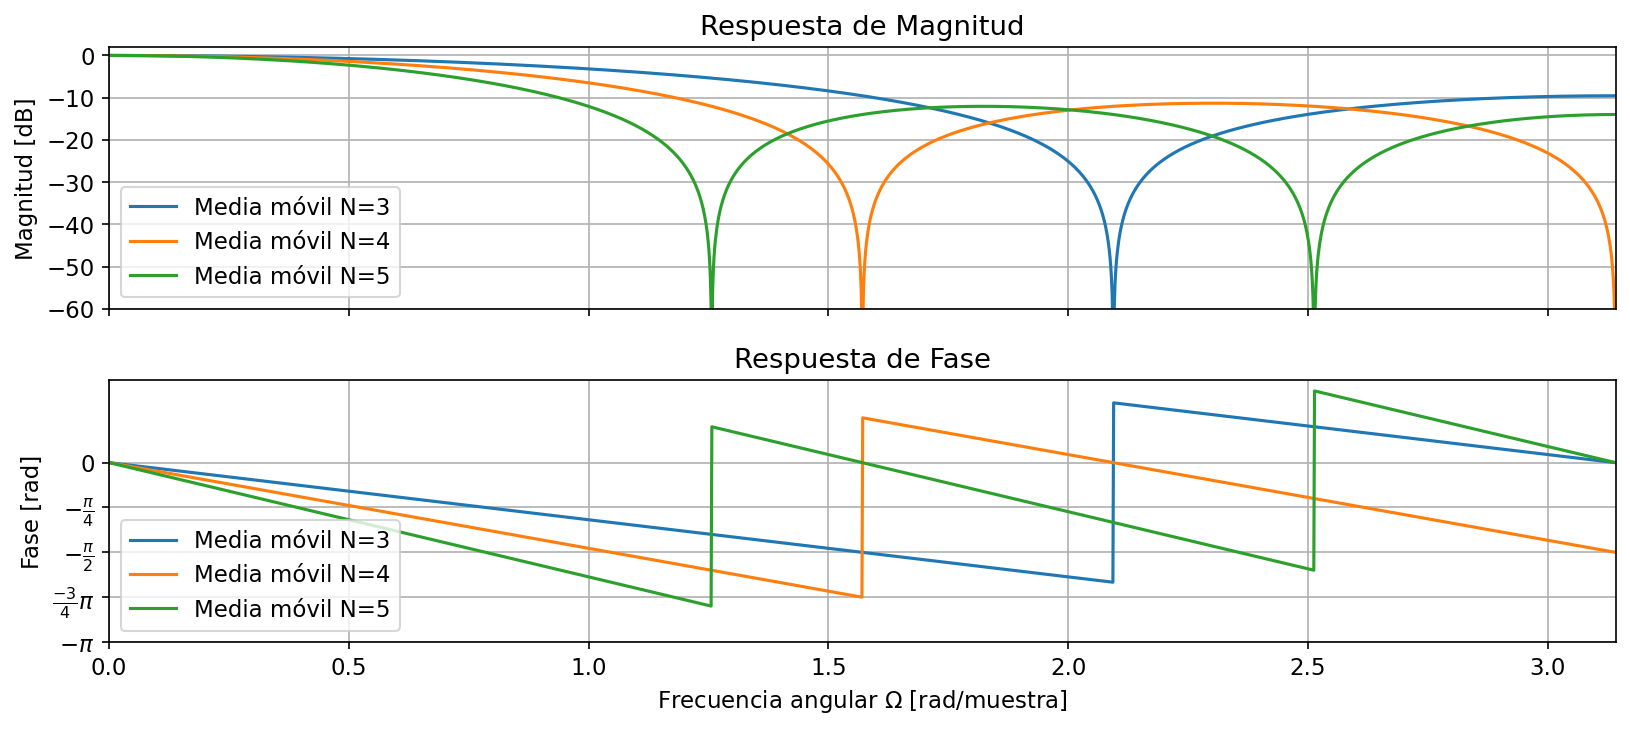

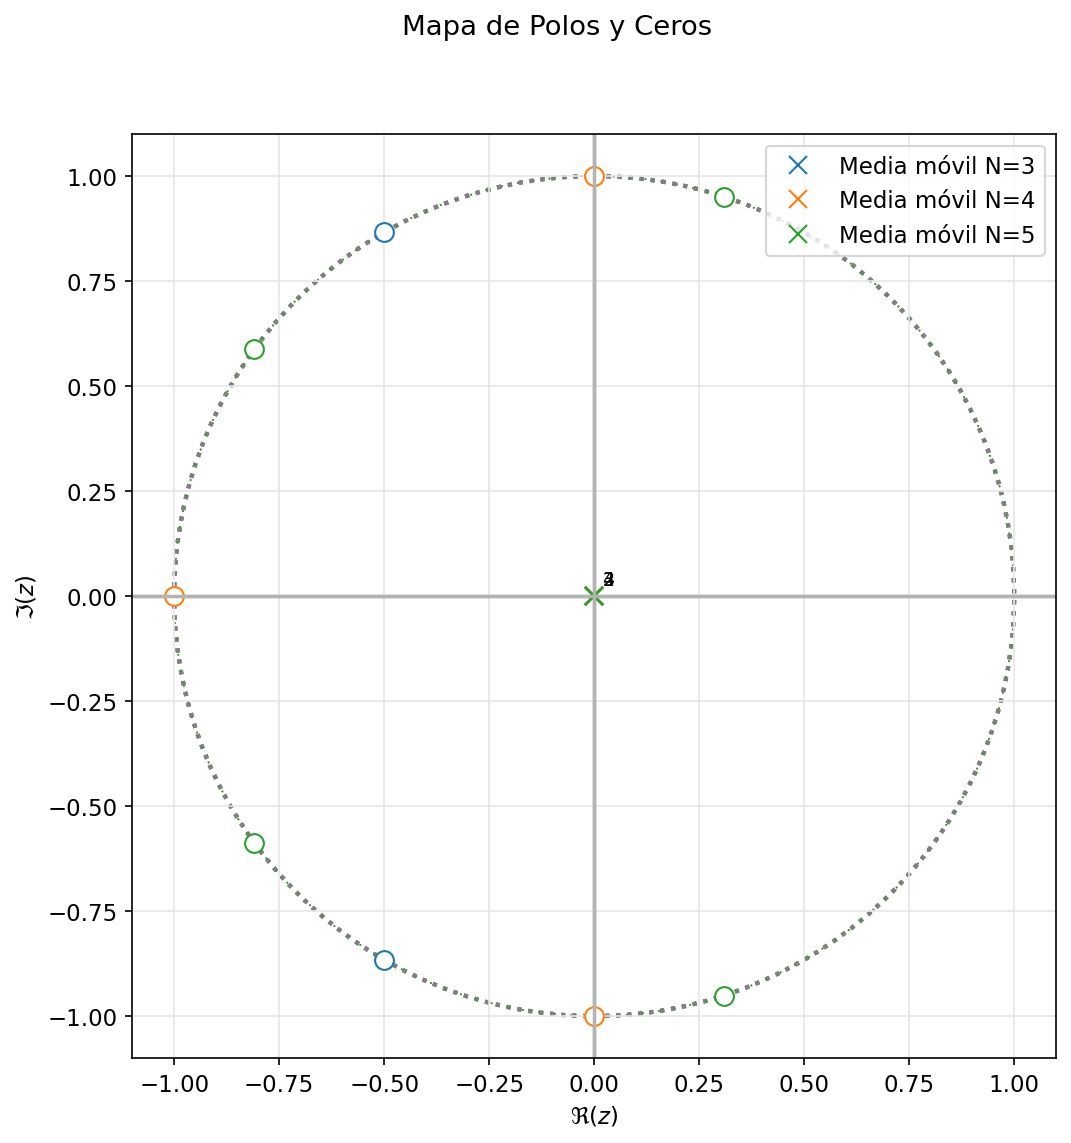

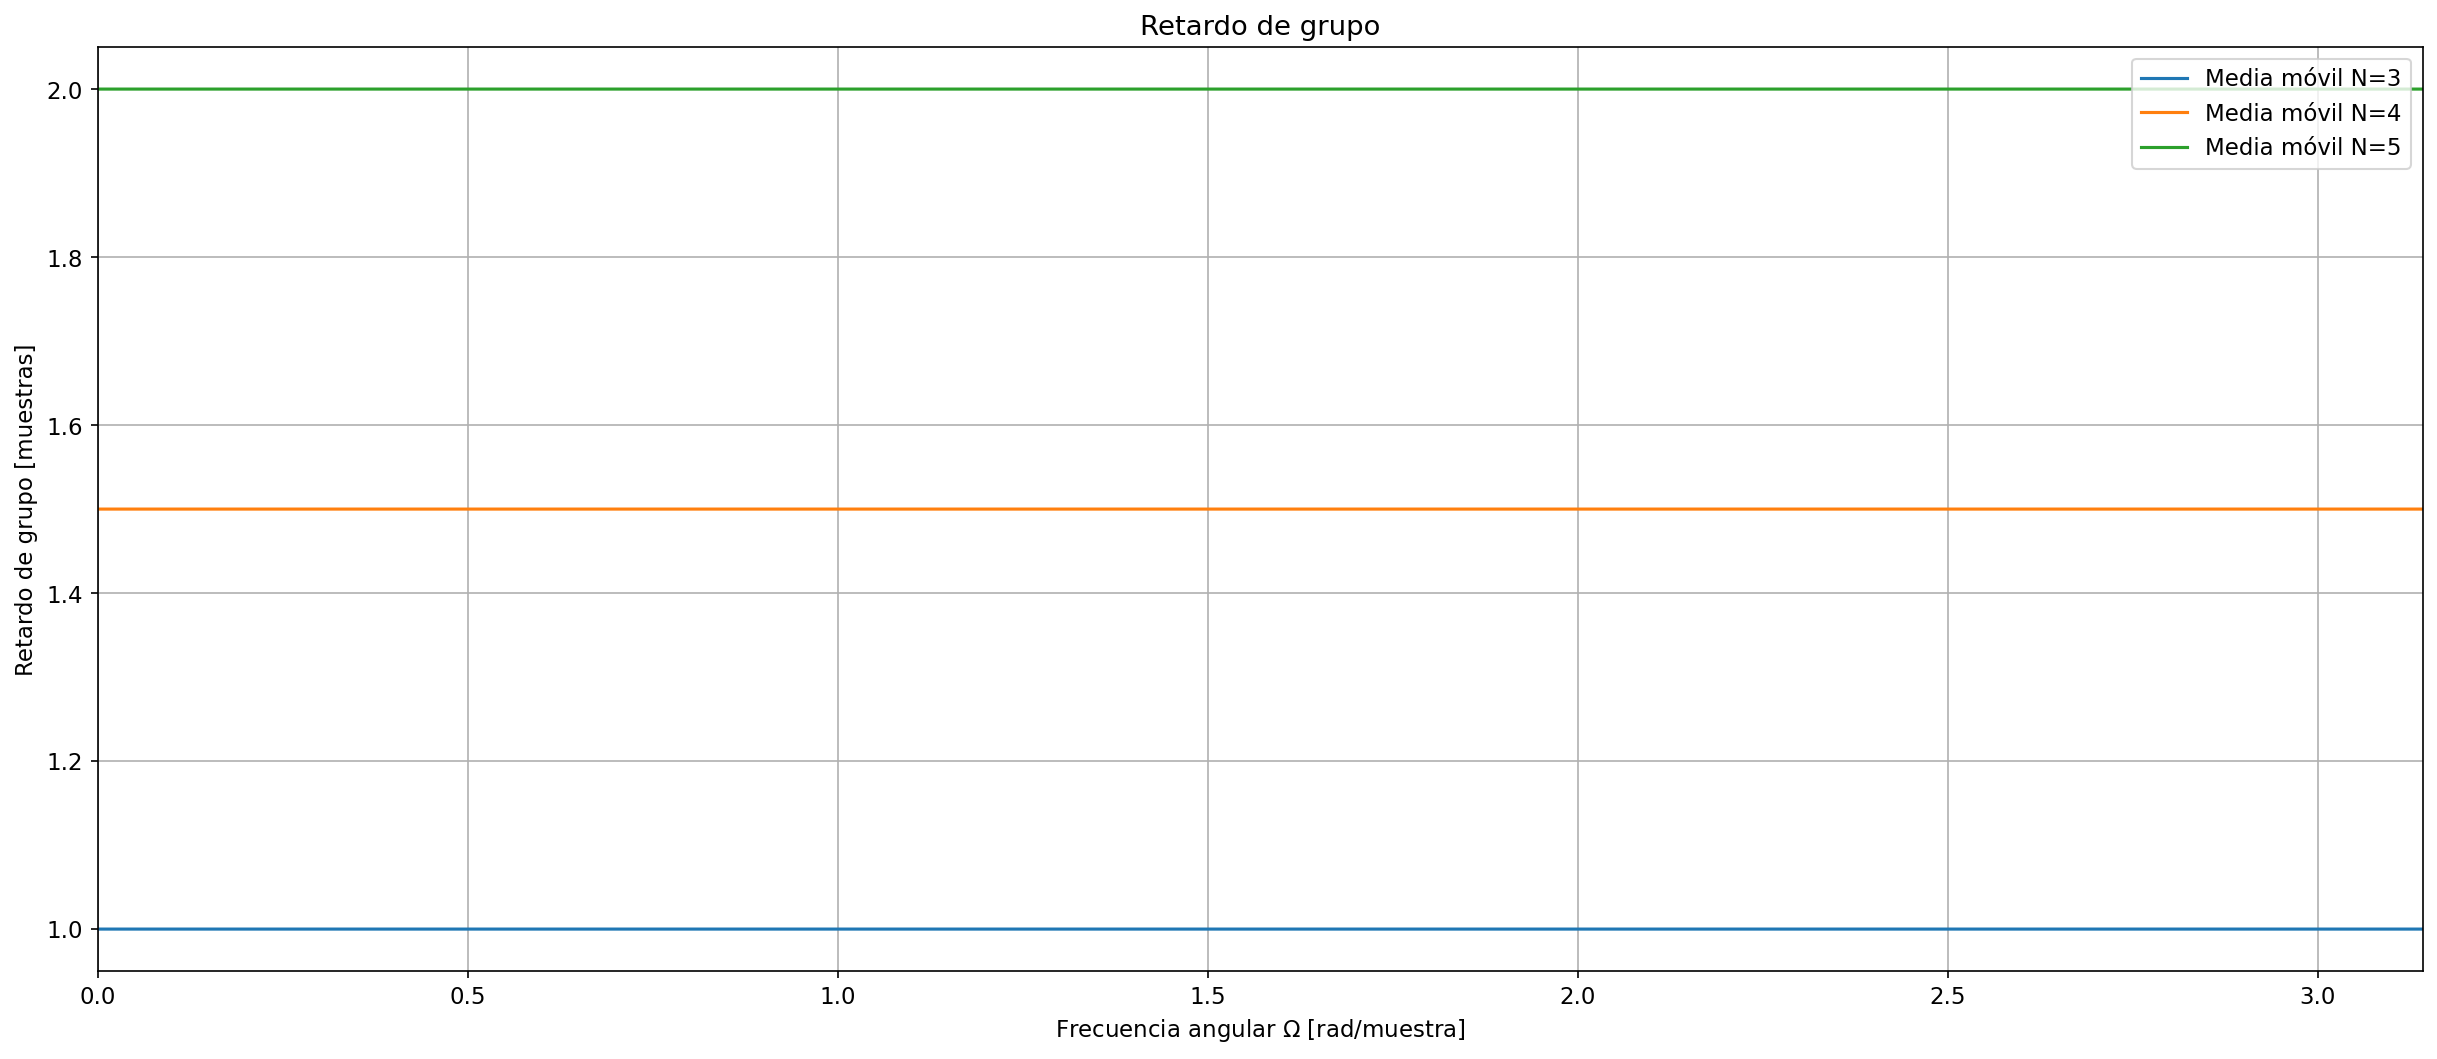

In [10]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import analyze_sys

valores_N = (3, 4, 5)
sistemas_media_movil = []
nombres_sistemas = []

for N in valores_N:
    # freqz/lfilter: coeficientes ordenados como 1, z^-1, ..., z^-(N-1).
    b_z_inv = np.ones(N) / N
    a_z_inv = np.array([1.0])

    # TransferFunction/analyze_sys: polinomios en potencias descendentes de z.
    # H(z) = (1/N)(z^(N-1) + ... + 1) / z^(N-1).
    num_z = b_z_inv.copy()
    den_z = np.r_[1.0, np.zeros(N - 1)]
    sistema = sig.TransferFunction(num_z, den_z, dt=1.0)

    omega = np.linspace(0.0, np.pi, 1024, endpoint=False)
    _, respuesta_z_inv = sig.freqz(b_z_inv, a_z_inv, worN=omega)
    _, respuesta_z = sistema.freqresp(w=omega)
    np.testing.assert_allclose(respuesta_z, respuesta_z_inv, atol=1e-12)

    sistemas_media_movil.append(sistema)
    nombres_sistemas.append(f'Media móvil N={N}')

analisis_media_movil = analyze_sys(
    sistemas_media_movil,
    sys_name=nombres_sistemas,
    worN=2048,
    same_figs=False,
    annotations=False,
    xaxis='omega',
    fs=2 * np.pi,
)

# En esta versión de pytc2 la etiqueta digital conserva "rad/seg".
# Como dt=1 muestra, la variable correcta es Omega en rad/muestra.
ejes_bode = analisis_media_movil[0][1]
for eje in ejes_bode:
    eje.set_xlim(0, np.pi)
ejes_bode[-1].set_xlabel(r'Frecuencia angular $\Omega$ [rad/muestra]')

# Los ceros llevan el autoescalado cerca de -320 dB; este rango muestra la zona útil.
eje_magnitud = ejes_bode[0]
eje_magnitud.set_ylim(-60, 2)
eje_magnitud.set_yticks(np.arange(-60, 1, 10))
eje_magnitud.figure.set_size_inches(11, 5)
eje_magnitud.figure.tight_layout()

eje_retardo = analisis_media_movil[3][1]
eje_retardo.set_xlim(0, np.pi)
eje_retardo.set_xlabel(r'Frecuencia angular $\Omega$ [rad/muestra]')
eje_retardo.set_ylabel('Retardo de grupo [muestras]')

plt.show()

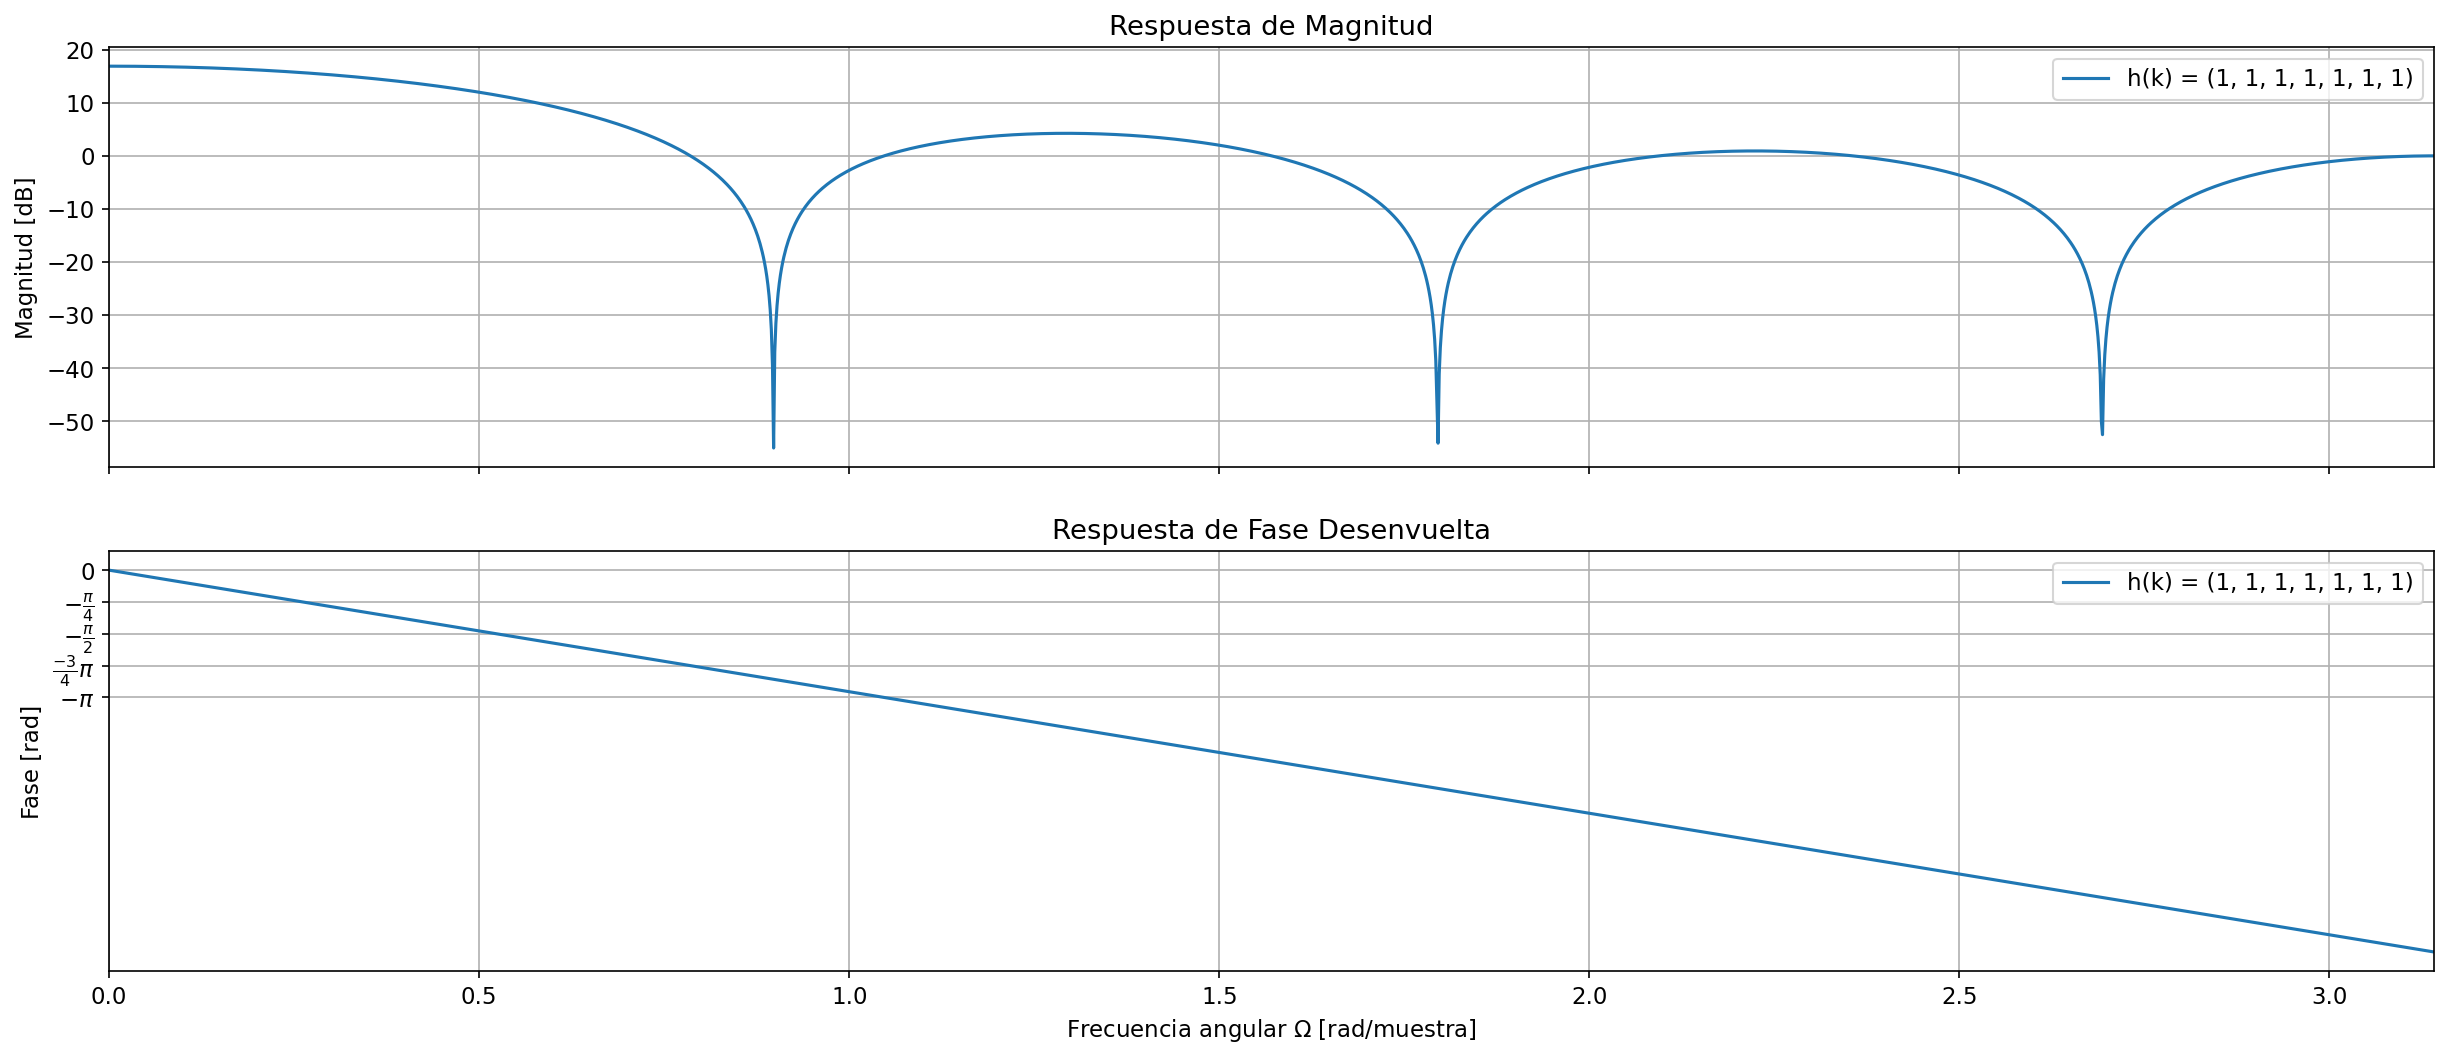

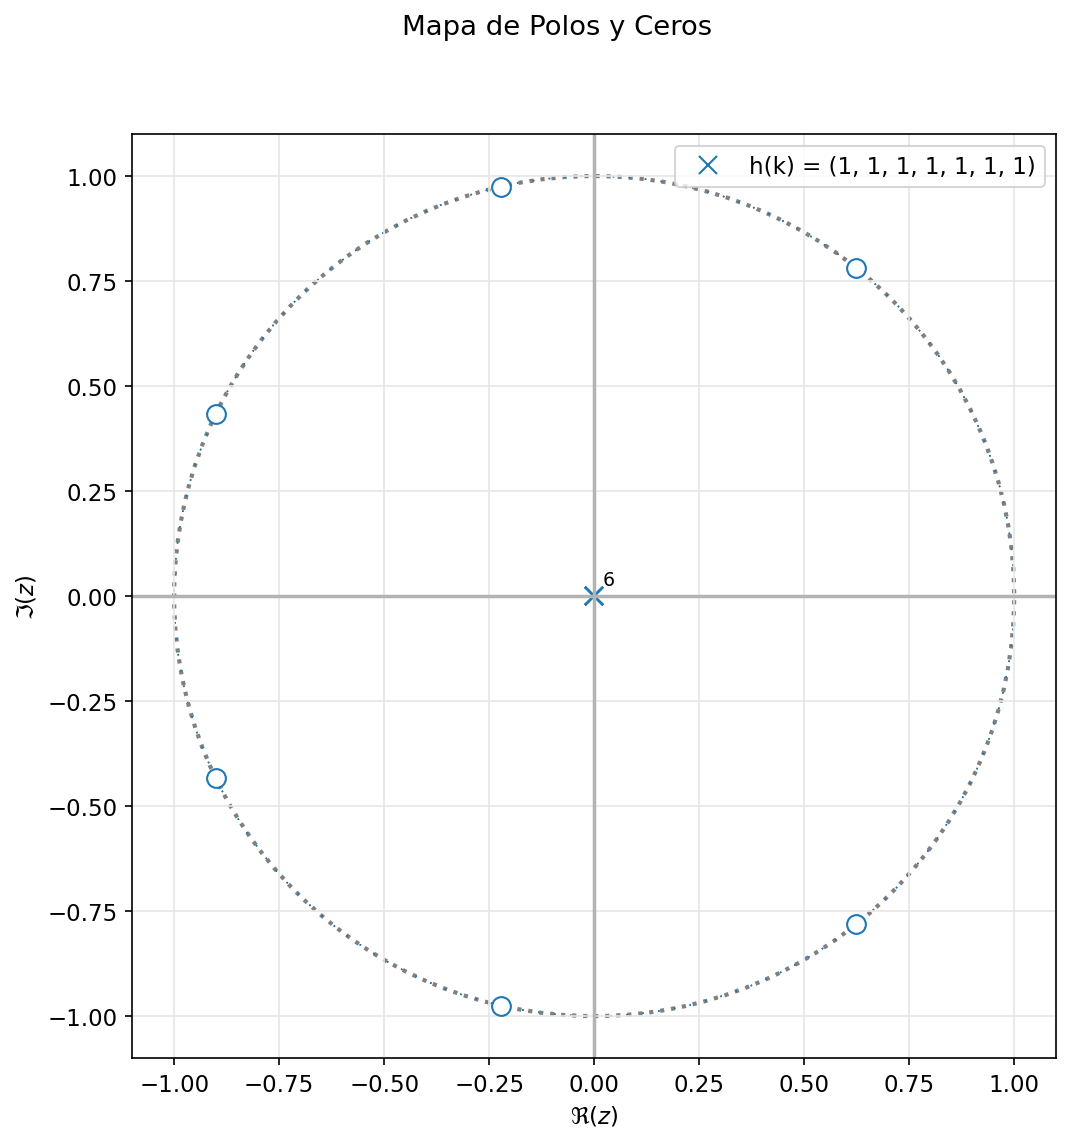

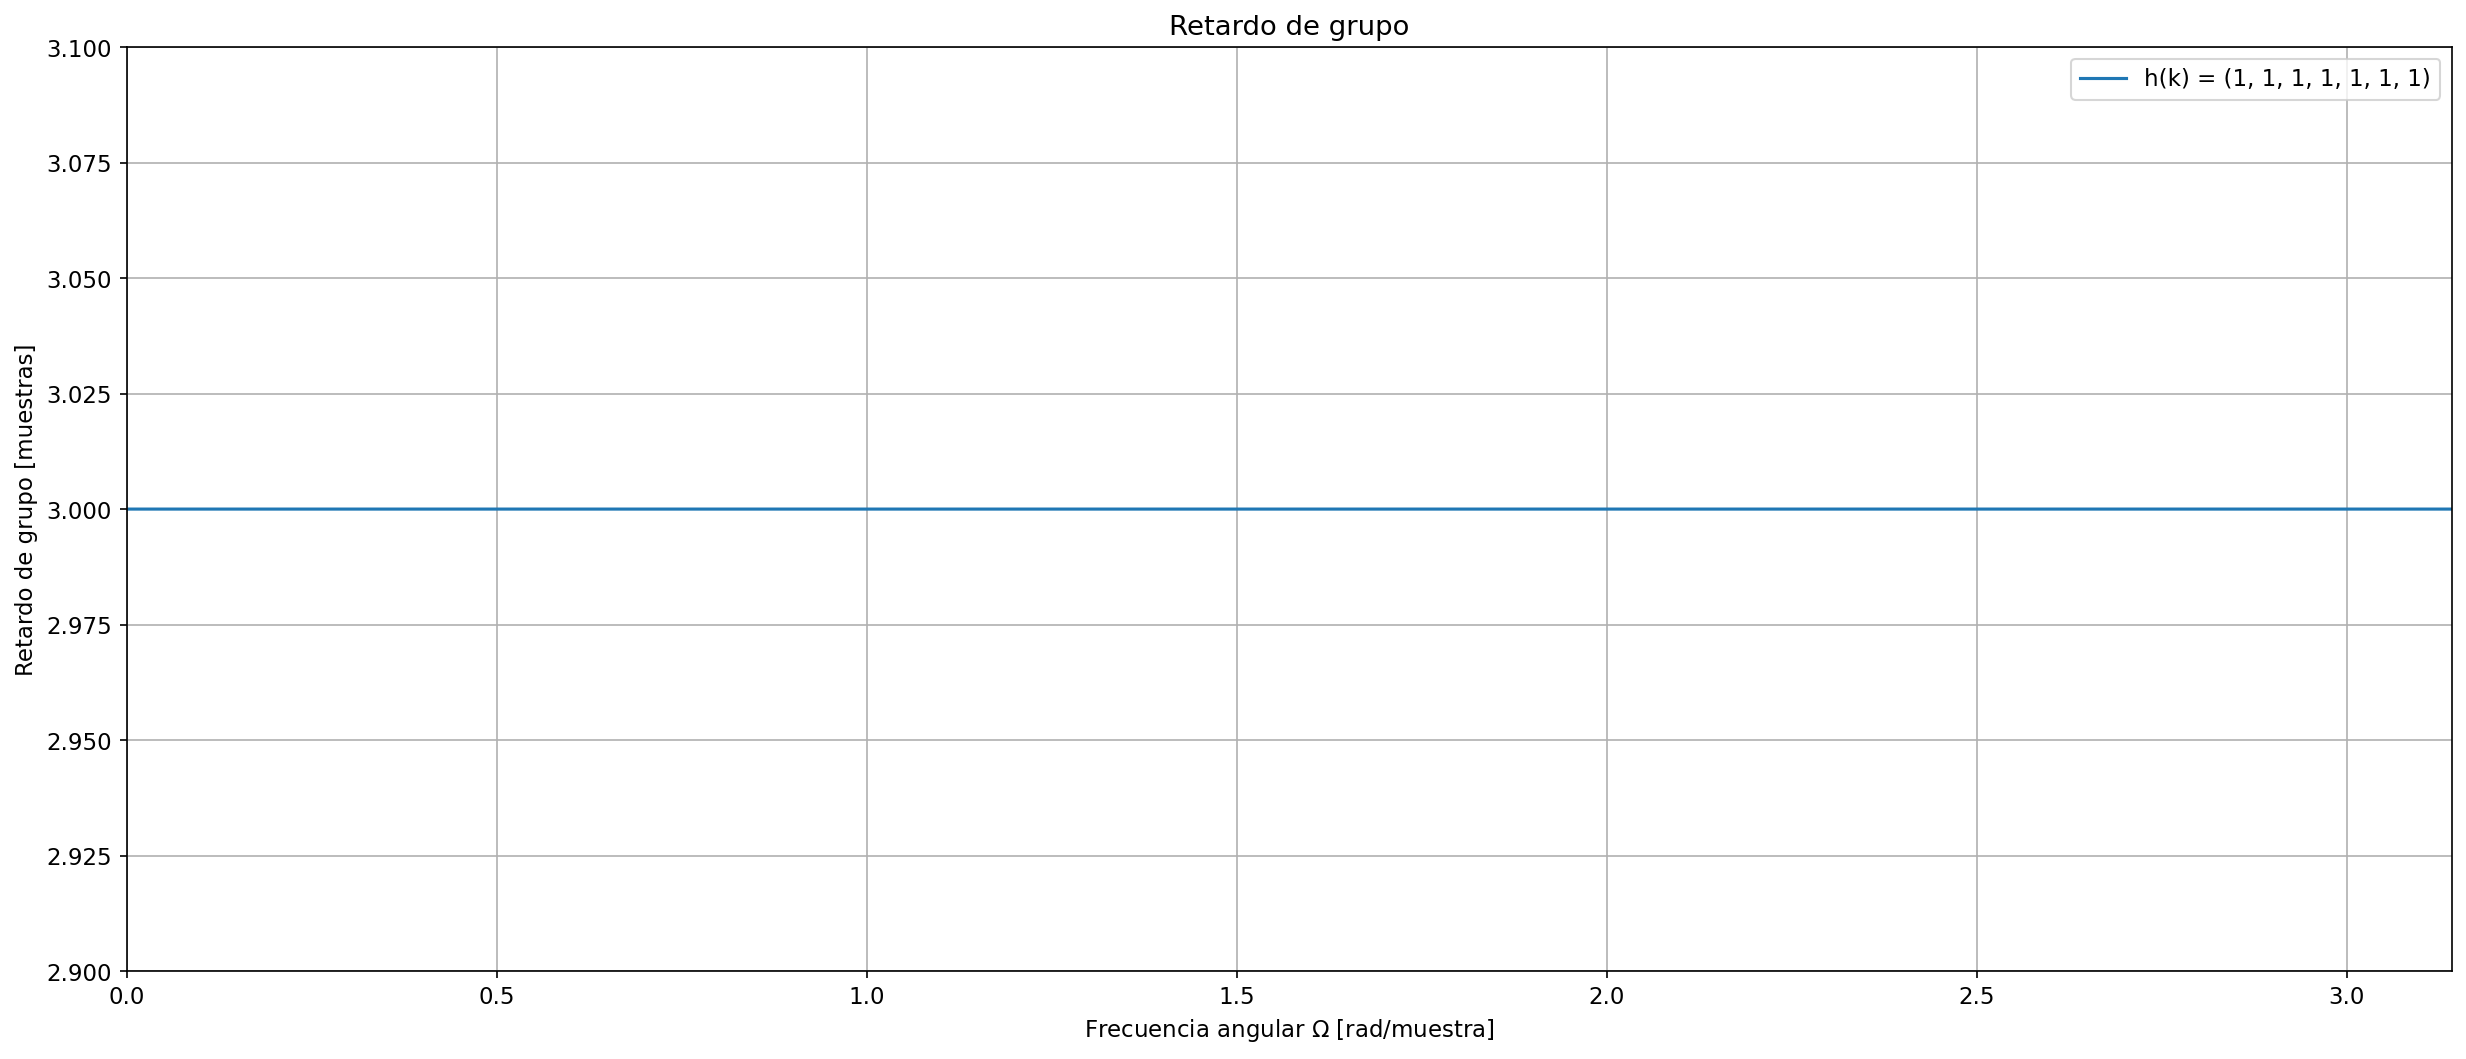

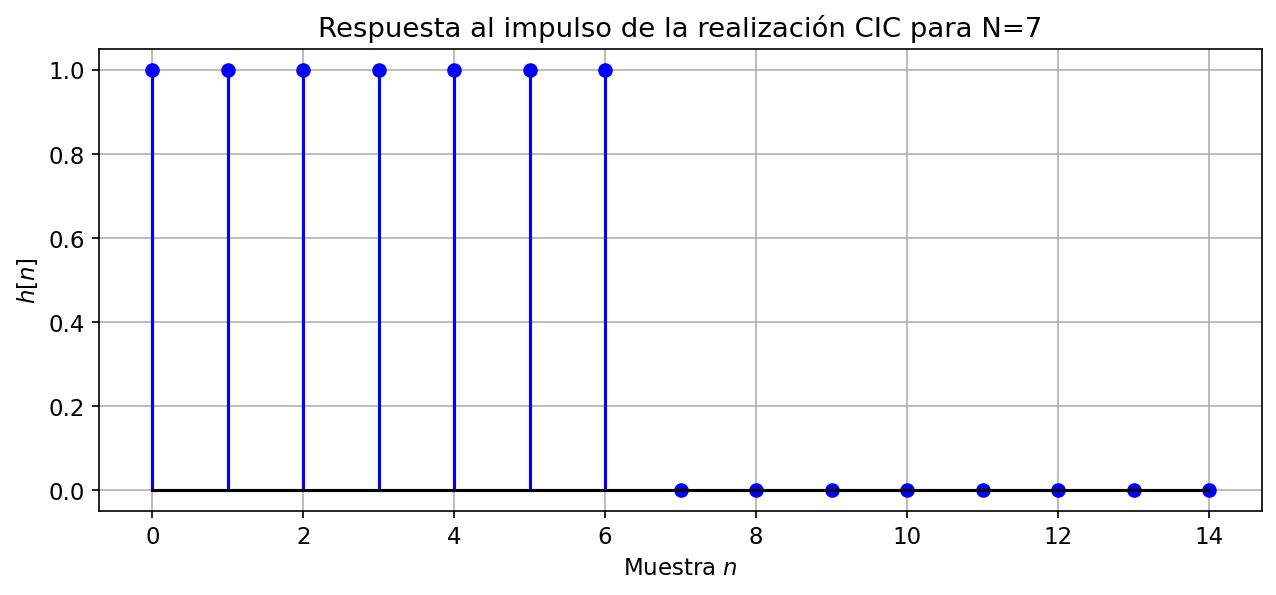

In [11]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from pytc2.sistemas_lineales import analyze_sys

N_objetivo = 7

# Forma FIR directa: H(z) = 1 + z^-1 + ... + z^-6.
b_fir = np.ones(N_objetivo)
a_fir = np.array([1.0])

# Realización CIC equivalente: (1 - z^-7) / (1 - z^-1).
b_cic = np.r_[1.0, np.zeros(N_objetivo - 1), -1.0]
a_cic = np.array([1.0, -1.0])

cantidad_muestras = 2 * N_objetivo + 1
n = np.arange(cantidad_muestras)
delta = np.zeros(cantidad_muestras)
delta[0] = 1.0

h_fir = sig.lfilter(b_fir, a_fir, delta)
h_cic = sig.lfilter(b_cic, a_cic, delta)
np.testing.assert_allclose(h_cic, h_fir, atol=1e-12)
np.testing.assert_allclose(h_cic[:N_objetivo], np.ones(N_objetivo))
np.testing.assert_allclose(h_cic[N_objetivo:], 0.0, atol=1e-12)

# Para analyze_sys se expresa la FIR reducida en potencias descendentes de z:
# H(z) = (z^6 + z^5 + ... + 1) / z^6.
num_z = np.ones(N_objetivo)
den_z = np.r_[1.0, np.zeros(N_objetivo - 1)]
sistema_h7 = sig.TransferFunction(num_z, den_z, dt=1.0)

omega = np.linspace(0.0, np.pi, 1024, endpoint=False)
_, respuesta_z_inv = sig.freqz(b_fir, a_fir, worN=omega)
_, respuesta_z = sistema_h7.freqresp(w=omega)
np.testing.assert_allclose(respuesta_z, respuesta_z_inv, atol=1e-12)

analisis_h7 = analyze_sys(
    sistema_h7,
    sys_name='h(k) = (1, 1, 1, 1, 1, 1, 1)',
    worN=2048,
    same_figs=False,
    annotations=False,
    xaxis='omega',
    fs=2 * np.pi,
)

for eje in analisis_h7[0][1]:
    eje.set_xlim(0, np.pi)

eje_fase = analisis_h7[0][1][1]
for linea in eje_fase.lines:
    linea.set_ydata(np.unwrap(linea.get_ydata(), period=np.pi))
eje_fase.relim()
eje_fase.autoscale_view(scalex=False, scaley=True)
eje_fase.set_title('Respuesta de Fase Desenvuelta')
eje_fase.set_xlabel(r'Frecuencia angular $\Omega$ [rad/muestra]')

eje_retardo = analisis_h7[3][1]
eje_retardo.set_xlim(0, np.pi)
eje_retardo.set_ylim(2.9, 3.1)
eje_retardo.ticklabel_format(axis='y', style='plain', useOffset=False)
eje_retardo.set_xlabel(r'Frecuencia angular $\Omega$ [rad/muestra]')
eje_retardo.set_ylabel('Retardo de grupo [muestras]')

plt.figure(figsize=(10, 4))
plt.stem(n, h_cic, basefmt='k-', linefmt='b-', markerfmt='bo')
plt.title('Respuesta al impulso de la realización CIC para N=7')
plt.xlabel('Muestra $n$')
plt.ylabel('$h[n]$')
plt.grid(True)
plt.show()

<a id="p3"></a>

***

## Punto 3 — Filtro diferenciador

Filtro **diferenciador** ( differentiator )

* Obtener los valores de $a_i$ y $b_k$ para obtener $y_{(n)} = \frac{x_{(n)} - x_{(n-2)}}{2}$
* Evaluar al sistema con un seno discreto en python y comprobar si la salida se aproxima a la derivada.

### Resolución analítica: filtro diferenciador

#### 0. Resolución manuscrita

<div>
  <img src="./img/punto_3_1.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_3_2.jpg" width="500" />
</div>

#### A. Obtención de los coeficientes

Se desea implementar

$$
y[n]=\frac{x[n]-x[n-2]}{2}
=\frac{1}{2}x[n]-\frac{1}{2}x[n-2].
$$

Aplicando la transformada Z con condiciones iniciales nulas:

$$
Y(z)=\frac{1}{2}X(z)-\frac{1}{2}z^{-2}X(z),
$$

por lo que

$$
\boxed{H(z)=\frac{Y(z)}{X(z)}
=\frac{1}{2}\left(1-z^{-2}\right)}.
$$

En la topología general del Punto 1 se anula el bloque peine mediante $c_1=0$. Como los coeficientes no indicados se consideran nulos, los valores son

$$
\boxed{
\begin{aligned}
a_0&=1, & a_1&=0, & a_2&=0,\\
b_0&=\frac{1}{2}, & b_1&=0, & b_2&=-\frac{1}{2},\\
c_1&=0.
\end{aligned}}
$$

El valor de $N$ no influye porque $c_1=0$. Para `scipy.signal.lfilter`, los vectores correspondientes son

$$
b=[0.5,\,0,\,-0.5],\qquad a=[1].
$$

#### B. Polos, ceros y diagrama en bloques

Para escribir la transferencia como cociente de polinomios en potencias positivas de $z$, multiplicamos por $z^2$:

$$
H(z)=\frac{z^2-1}{2z^2}
=\frac{(z-1)(z+1)}{2z^2}.
$$

Por lo tanto:

* ceros simples en $z_1=1$ y $z_2=-1$;
* un polo doble en $z=0$, asociado a los dos retardos de la realización causal.

Los polos están dentro de la circunferencia unitaria y, además, la respuesta al impulso tiene duración finita. Por ello el sistema es FIR y estable

Una representación compacta del diagrama en bloques es

$$
X(z)\;\longrightarrow\;\boxed{1-z^{-2}}
\;\longrightarrow\;\boxed{\frac{1}{2}}
\;\longrightarrow\;Y(z).
$$

Equivalentemente, la entrada se divide en una rama directa de ganancia $1/2$ y otra con dos retardos y ganancia $-1/2$; ambas ramas se suman para producir $y[n]$.

#### C. Respuesta en frecuencia

Evaluamos la transferencia sobre la circunferencia unitaria, $z=e^{j\Omega}$:

$$
H(e^{j\Omega})=\frac{1}{2}\left(1-e^{-j2\Omega}\right).
$$

Usando

$$
1-e^{-j2\Omega}
=e^{-j\Omega}\left(e^{j\Omega}-e^{-j\Omega}\right)
=2j\,e^{-j\Omega}\sin(\Omega),
$$

se obtiene

$$
\boxed{H(e^{j\Omega})=j\,e^{-j\Omega}\sin(\Omega)}.
$$

La magnitud es

$$
\boxed{\left|H(e^{j\Omega})\right|=|\sin(\Omega)|}.
$$

Los ceros $z=1$ y $z=-1$ corresponden respectivamente a

$$
\Omega=0\qquad\text{y}\qquad\Omega=\pi,
$$

de modo que el filtro elimina tanto la componente continua como la frecuencia de Nyquist.

Para obtener la fase se separan los tres factores:

$$
\arg(j)=\frac{\pi}{2},\qquad
\arg(e^{-j\Omega})=-\Omega,
$$

mientras que $\sin(\Omega)$ aporta fase $0$ si es positivo y $\pi$ si es negativo. En el intervalo principal $-\pi<\Omega<\pi$:

$$
\boxed{
\phi(\Omega)=
\begin{cases}
-\dfrac{\pi}{2}-\Omega, & -\pi<\Omega<0,\\[6pt]
\dfrac{\pi}{2}-\Omega, & 0<\Omega<\pi,
\end{cases}}
$$

módulo $2\pi$. En $\Omega=0$ y $\Omega=\pm\pi$ la fase no está definida porque la magnitud es cero.

El término $e^{-j\Omega}$ representa un retardo lineal de una muestra. Por eso el retardo de grupo, donde la respuesta no se anula, es

$$
\tau_g(\Omega)=-\frac{d\phi}{d\Omega}=1\ \text{muestra}.
$$

#### D. Comparación con un diferenciador ideal

La respuesta de un diferenciador ideal discreto es

$$
H_{\mathrm{ideal}}(e^{j\Omega})=j\Omega.
$$

Como el filtro estudiado tiene un retardo de una muestra, la comparación adecuada es con el diferenciador ideal retardado:

$$
H_{\mathrm{ideal,ret}}(e^{j\Omega})
=j\Omega e^{-j\Omega}.
$$

Para bajas frecuencias se cumple $\sin(\Omega)\approx\Omega$, y entonces

$$
H(e^{j\Omega})
=j e^{-j\Omega}\sin(\Omega)
\approx j\Omega e^{-j\Omega}.
$$

Por lo tanto, el filtro aproxima la derivada evaluada una muestra antes, no la derivada sin retardo.

#### E. Evaluación con un seno discreto

Sea

$$
x[n]=\sin(\Omega_0 n).
$$

La salida exacta en régimen permanente se obtiene mediante la identidad

$$
\sin(A)-\sin(B)
=2\cos\left(\frac{A+B}{2}\right)
\sin\left(\frac{A-B}{2}\right):
$$

$$
\begin{aligned}
y[n]
&=\frac{1}{2}\left[\sin(\Omega_0 n)-\sin(\Omega_0(n-2))\right]\\
&=\boxed{\sin(\Omega_0)\cos\left(\Omega_0(n-1)\right)}.
\end{aligned}
$$

La derivada ideal, también retardada una muestra, es

$$
\left.\frac{dx}{dn}\right|_{n-1}
=\Omega_0\cos\left(\Omega_0(n-1)\right).
$$

Ambas señales tienen la misma forma y fase, pero sus amplitudes difieren por el factor

$$
\boxed{G_{\mathrm{rel}}(\Omega_0)
=\frac{\sin(\Omega_0)}{\Omega_0}}.
$$

Este cociente tiende a uno cuando $\Omega_0\to0$, lo cual demuestra que la aproximación mejora a bajas frecuencias. Para $f_0=0.05$ ciclos/muestra,

$$
\Omega_0=2\pi f_0=0.1\pi\approx0.3142\ \text{rad/muestra},
$$

$$
G_{\mathrm{rel}}\approx0.9836,
$$

por lo que la amplitud de la salida es aproximadamente un $1.64\%$ menor que la de la derivada ideal retardada. Las dos primeras muestras de `lfilter` corresponden al transitorio causado por asumir condiciones iniciales nulas.

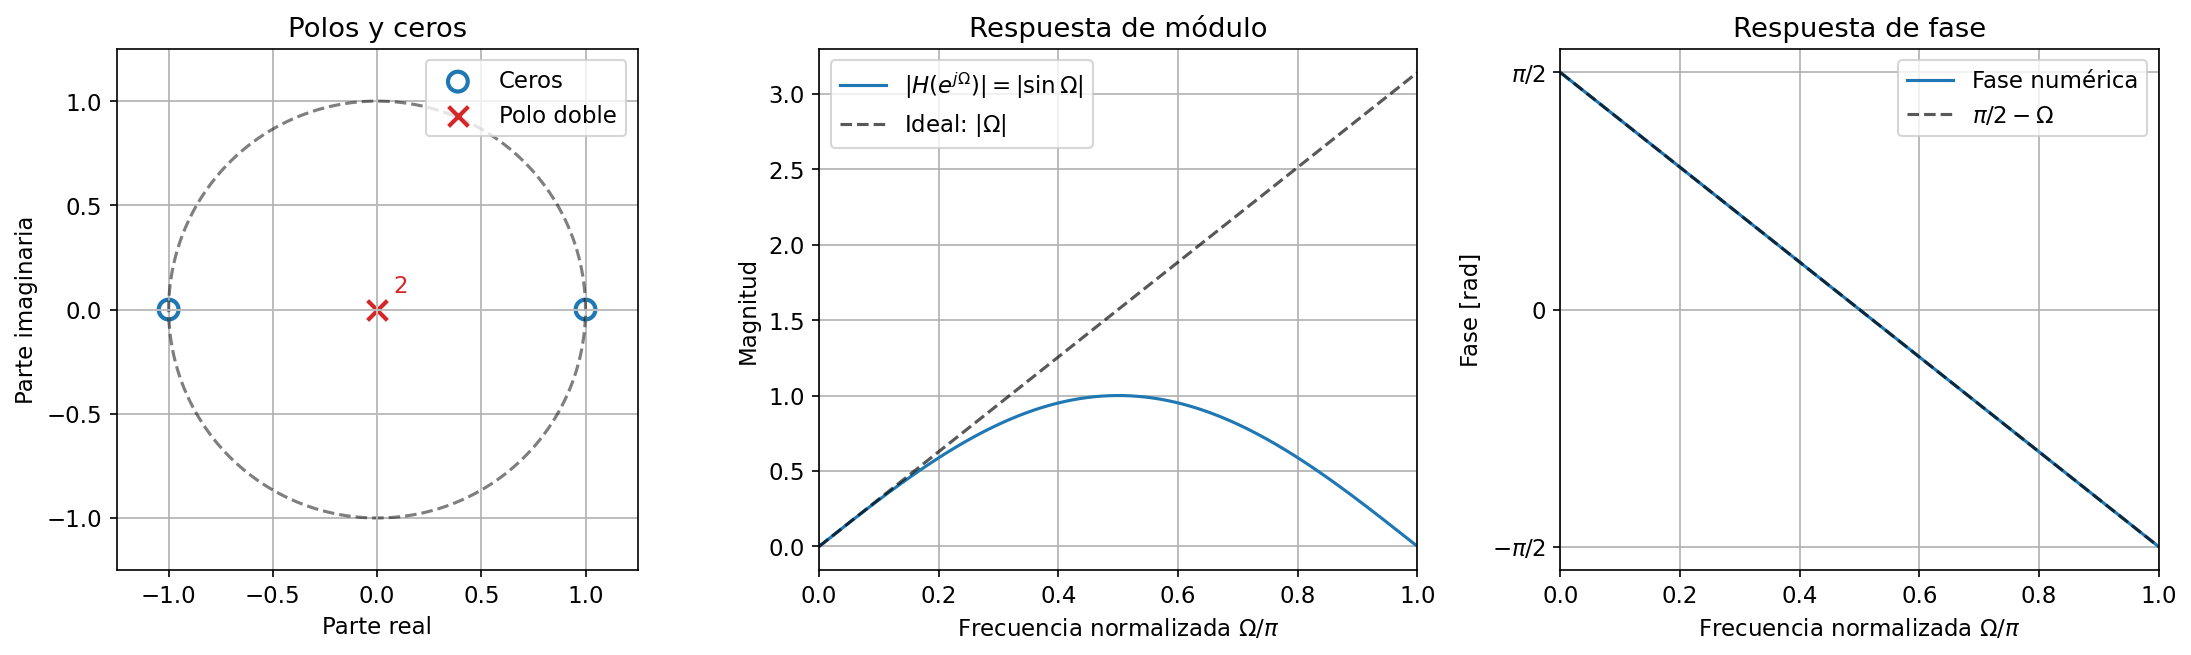

Omega_0 = 0.314159 rad/muestra
Amplitud del filtro = sin(Omega_0) = 0.309017
Amplitud de la derivada ideal = Omega_0 = 0.314159
Ganancia relativa = 0.983632
Error de amplitud = 1.637 %


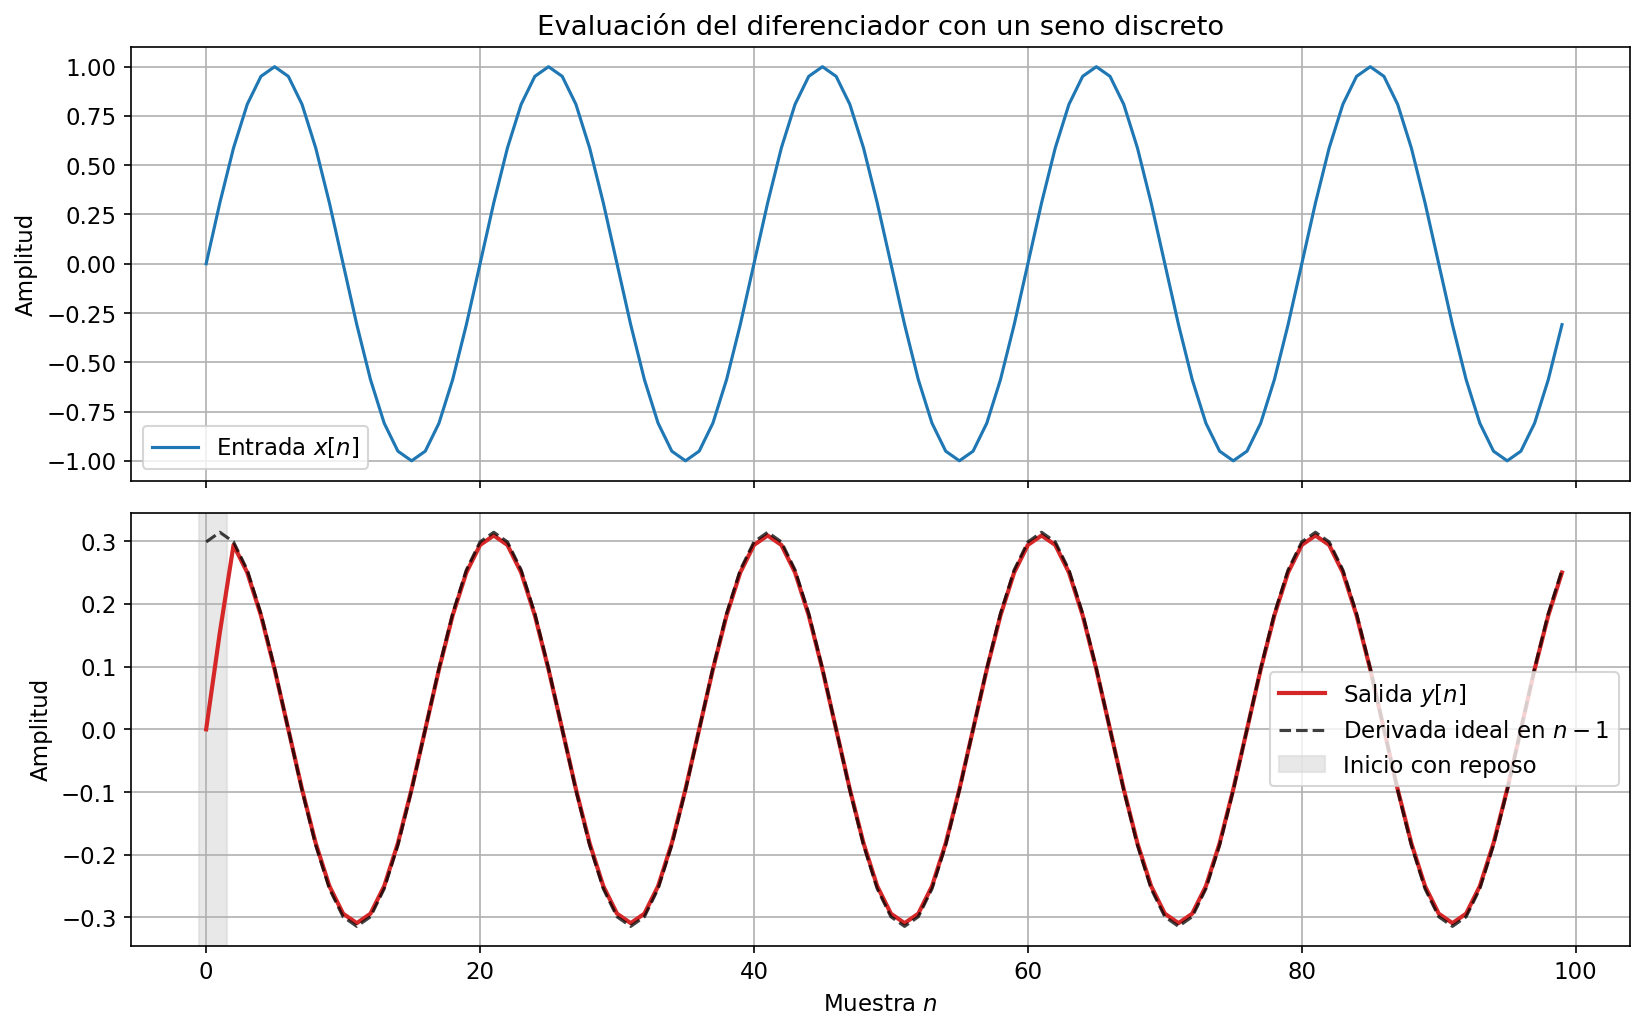

In [12]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt

# Coeficientes para lfilter, ordenados como 1, z^-1, z^-2.
b_dif = np.array([0.5, 0.0, -0.5])
a_dif = np.array([1.0])

# Respuesta en frecuencia y comprobación de la expresión analítica.
omega_dif, respuesta_dif = sig.freqz(b_dif, a_dif, worN=2048)
respuesta_analitica = 1j * np.exp(-1j * omega_dif) * np.sin(omega_dif)
np.testing.assert_allclose(respuesta_dif, respuesta_analitica, atol=1e-12)

magnitud_dif = np.abs(respuesta_dif)
fase_dif = np.angle(respuesta_dif)
frecuencias_validas = magnitud_dif > 1e-10

# En potencias positivas de z: H(z) = (z^2 - 1) / (2 z^2).
ceros_dif = np.roots([0.5, 0.0, -0.5])
polos_dif = np.array([0.0, 0.0])

figura, ejes = plt.subplots(1, 3, figsize=(15, 4.5))

angulo_circulo = np.linspace(0, 2 * np.pi, 400)
ejes[0].plot(np.cos(angulo_circulo), np.sin(angulo_circulo), 'k--', alpha=0.5)
ejes[0].scatter(
    ceros_dif.real,
    ceros_dif.imag,
    s=90,
    facecolors='none',
    edgecolors='C0',
    linewidths=2,
    label='Ceros',
)
ejes[0].scatter(0, 0, s=90, marker='x', color='C3', linewidths=2, label='Polo doble')
ejes[0].annotate('2', (0, 0), xytext=(8, 8), textcoords='offset points', color='C3')
ejes[0].axhline(0, color='0.75', linewidth=0.8)
ejes[0].axvline(0, color='0.75', linewidth=0.8)
ejes[0].set(xlim=(-1.25, 1.25), ylim=(-1.25, 1.25), xlabel='Parte real', ylabel='Parte imaginaria', title='Polos y ceros')
ejes[0].set_aspect('equal', adjustable='box')
ejes[0].grid(True)
ejes[0].legend(loc='upper right')

ejes[1].plot(omega_dif / np.pi, magnitud_dif, label=r'$|H(e^{j\Omega})|=|\sin\Omega|$')
ejes[1].plot(omega_dif / np.pi, omega_dif, 'k--', alpha=0.65, label=r'Ideal: $|\Omega|$')
ejes[1].set(xlabel=r'Frecuencia normalizada $\Omega/\pi$', ylabel='Magnitud', title='Respuesta de módulo')
ejes[1].set_xlim(0, 1)
ejes[1].grid(True)
ejes[1].legend()

ejes[2].plot(
    omega_dif[frecuencias_validas] / np.pi,
    fase_dif[frecuencias_validas],
    label='Fase numérica',
)
ejes[2].plot(
    omega_dif[frecuencias_validas] / np.pi,
    np.pi / 2 - omega_dif[frecuencias_validas],
    'k--',
    alpha=0.65,
    label=r'$\pi/2-\Omega$',
)
ejes[2].set(xlabel=r'Frecuencia normalizada $\Omega/\pi$', ylabel='Fase [rad]', title='Respuesta de fase')
ejes[2].set_xlim(0, 1)
ejes[2].set_yticks([-np.pi / 2, 0, np.pi / 2], [r'$-\pi/2$', '0', r'$\pi/2$'])
ejes[2].grid(True)
ejes[2].legend()

figura.tight_layout()
plt.show()

# Evaluación con una señal senoidal.
cantidad_muestras_dif = 100
n_dif = np.arange(cantidad_muestras_dif)
f0 = 0.05  # ciclos/muestra
omega_0 = 2 * np.pi * f0
x_dif = np.sin(omega_0 * n_dif)
y_dif = sig.lfilter(b_dif, a_dif, x_dif)

# Salida exacta y derivada ideal, ambas referidas a n - 1.
salida_exacta = np.sin(omega_0) * np.cos(omega_0 * (n_dif - 1))
derivada_ideal_retardada = omega_0 * np.cos(omega_0 * (n_dif - 1))
regimen_permanente = n_dif >= 2
np.testing.assert_allclose(
    y_dif[regimen_permanente],
    salida_exacta[regimen_permanente],
    atol=1e-12,
)

ganancia_relativa = np.sin(omega_0) / omega_0
error_amplitud_porcentual = 100 * (1 - ganancia_relativa)
print(f'Omega_0 = {omega_0:.6f} rad/muestra')
print(f'Amplitud del filtro = sin(Omega_0) = {np.sin(omega_0):.6f}')
print(f'Amplitud de la derivada ideal = Omega_0 = {omega_0:.6f}')
print(f'Ganancia relativa = {ganancia_relativa:.6f}')
print(f'Error de amplitud = {error_amplitud_porcentual:.3f} %')

figura, ejes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ejes[0].plot(n_dif, x_dif, color='C0', label=r'Entrada $x[n]$')
ejes[0].set(title='Evaluación del diferenciador con un seno discreto', ylabel='Amplitud')
ejes[0].grid(True)
ejes[0].legend()

ejes[1].plot(n_dif, y_dif, color='C3', linewidth=2, label=r'Salida $y[n]$')
ejes[1].plot(
    n_dif,
    derivada_ideal_retardada,
    'k--',
    alpha=0.75,
    label=r'Derivada ideal en $n-1$',
)
ejes[1].axvspan(-0.5, 1.5, color='0.85', alpha=0.6, label='Inicio con reposo')
ejes[1].set(xlabel='Muestra $n$', ylabel='Amplitud')
ejes[1].grid(True)
ejes[1].legend()

figura.tight_layout()
plt.show()

#### Conclusiones del filtro diferenciador

* Los coeficientes $b=[0.5,\,0,\,-0.5]$ y $a=[1]$ implementan una diferencia central causal de dos muestras. El filtro es FIR de orden 2 y tiene un retardo de grupo de una muestra.
* La respuesta exacta es $H(e^{j\Omega})=j e^{-j\Omega}\sin(\Omega)$. Solo para $|\Omega|\ll\pi$ puede usarse $\sin(\Omega)\approx\Omega$ y considerar al sistema un diferenciador ideal retardado.
* Los ceros en $z=1$ y $z=-1$ anulan la respuesta en continua ($\Omega=0$) y en la frecuencia de Nyquist ($\Omega=\pi$). Al escribir la transferencia en potencias positivas de $z$ aparece además un polo doble en el origen.
* Para $f_0=0.05$ ciclos/muestra, la salida tiene la forma cosenoidal y el retardo esperados, pero su amplitud es $\sin(0.1\pi)=0.309017$ en lugar de $0.1\pi=0.314159$. El error de amplitud respecto de la derivada ideal retardada es $1.637\%$.
* Las dos primeras muestras constituyen el transitorio de inicio porque `lfilter` supone que las muestras anteriores a $n=0$ son nulas. Desde $n=2$, la simulación coincide con $y[n]=\sin(\Omega_0)\cos[\Omega_0(n-1)]$ dentro de la precisión numérica.

<a id="p4"></a>

***

## Punto 4 — Filtro elimina continua

Filtro **elimina continua** ( DC Blocker )

* Verifique la transferencia para $a_0 = 1$, $a_1 = \beta$, $b_0 = 1$, $b_1 = -1$ para $\beta = 0.9$
* Determine $\beta$ para que la transferencia en $\Omega = 0,1 \cdot \pi$ sea 3 dB menor a la transferencia en $\Omega = \pi$

### Resolución analítica: filtro elimina continua

#### 0. Resolución manuscrita

<div>
  <img src="./img/punto_4_1.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_4_2.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_4_3.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_4_4.jpg" width="500" />
</div>

#### A. Transferencia, ecuación en diferencias y clasificación

Los coeficientes no indicados se consideran nulos. Para anular el bloque peine se toma $c_1=0$ y, con los valores de la consigna,

$$
a_0=1,\qquad a_1=\beta,\qquad a_2=0,
$$

$$
b_0=1,\qquad b_1=-1,\qquad b_2=0.
$$

Al sustituirlos en la transferencia general resulta

$$
\boxed{H_{DC}(z)=\frac{1-z^{-1}}{1-\beta z^{-1}}}
=\frac{z-1}{z-\beta}.
$$

Como $H_{DC}(z)=Y(z)/X(z)$,

$$
(1-\beta z^{-1})Y(z)=(1-z^{-1})X(z).
$$

Desarrollando ambos miembros y aplicando la antitransformada Z:

$$
y[n]-\beta y[n-1]=x[n]-x[n-1].
$$

Por lo tanto, la ecuación en diferencias es

$$
\boxed{y[n]=\beta y[n-1]+x[n]-x[n-1]}.
$$

La presencia de $y[n-1]$ muestra que la salida actual depende de una salida anterior: existe realimentación. Para $\beta\neq0$, esta recurrencia no termina después de una cantidad finita de muestras, por lo que el filtro es **IIR**.

La misma clasificación se confirma mediante la respuesta al impulso. Para $|z|>|\beta|$,

$$
\frac{1}{1-\beta z^{-1}}
=\sum_{k=0}^{\infty}\beta^kz^{-k}.
$$

Entonces,

$$
\begin{aligned}
H_{DC}(z)
&=(1-z^{-1})\sum_{k=0}^{\infty}\beta^kz^{-k}\\[4pt]
&=1+(\beta-1)\sum_{k=1}^{\infty}\beta^{k-1}z^{-k}.
\end{aligned}
$$

Por antitransformada Z,

$$
\boxed{
h[n]=\delta[n]+(\beta-1)\beta^{n-1}u[n-1]}.
$$

Para $0<|\beta|<1$, esta respuesta decrece, pero contiene infinitas muestras no nulas. Esto confirma que el filtro es IIR y concuerda con el polo en $z=\beta$.

#### B. Polos y ceros

La forma $H_{DC}(z)=(z-1)/(z-\beta)$ permite leer directamente:

$$
z_0=1,\qquad p_0=\beta.
$$

El cero en $z=1$ anula la continua porque $z=e^{j\Omega}=1$ para $\Omega=0$. El sistema causal es estable si

$$
\boxed{|\beta|<1}.
$$

Para $\beta=0.9$, el polo está en $z=0.9$, dentro de la circunferencia unitaria.

#### C. Respuesta de módulo y fase

Sobre la circunferencia unitaria:

$$
H_{DC}(e^{j\Omega})
=\frac{1-e^{-j\Omega}}{1-\beta e^{-j\Omega}}.
$$

El módulo al cuadrado se obtiene multiplicando cada factor por su conjugado:

$$
\begin{aligned}
|1-e^{-j\Omega}|^2&=2-2\cos\Omega,\\
|1-\beta e^{-j\Omega}|^2&=1+\beta^2-2\beta\cos\Omega.
\end{aligned}
$$

Veamos con más detalle la igualdad correspondiente al numerador. Como el conjugado de $1-e^{-j\Omega}$ es $1-e^{j\Omega}$,

$$
\begin{aligned}
|1-e^{-j\Omega}|^2
&=(1-e^{-j\Omega})(1-e^{j\Omega})\\[4pt]
&=1-e^{j\Omega}-e^{-j\Omega}+1\\[4pt]
&=2-\left(e^{j\Omega}+e^{-j\Omega}\right)\\[4pt]
&=2-2\cos\Omega,
\end{aligned}
$$

donde se utilizó la identidad de Euler

$$
e^{j\Omega}+e^{-j\Omega}=2\cos\Omega.
$$

Luego se aplica la identidad de ángulo mitad

$$
1-\cos\Omega=2\sin^2\left(\frac{\Omega}{2}\right).
$$

De esta manera,

$$
\begin{aligned}
2-2\cos\Omega
&=2(1-\cos\Omega)\\[4pt]
&=4\sin^2\left(\frac{\Omega}{2}\right).
\end{aligned}
$$

Finalmente se toma la raíz cuadrada para obtener el módulo del numerador:

$$
\begin{aligned}
|1-e^{-j\Omega}|
&=\sqrt{2-2\cos\Omega}\\[4pt]
&=\sqrt{4\sin^2\left(\frac{\Omega}{2}\right)}\\[4pt]
&=2\left|\sin\left(\frac{\Omega}{2}\right)\right|.
\end{aligned}
$$

El valor absoluto aparece porque $\sqrt{a^2}=|a|$. En el intervalo $0\leq\Omega\leq\pi$, se cumple $\sin(\Omega/2)\geq0$ y podría omitirse, pero se conserva para que la expresión sea válida para cualquier $\Omega$.

Por lo tanto,

$$
\boxed{
|H_{DC}(e^{j\Omega})|
=\sqrt{\frac{2-2\cos\Omega}
{1+\beta^2-2\beta\cos\Omega}}
=\frac{2|\sin(\Omega/2)|}
{\sqrt{1+\beta^2-2\beta\cos\Omega}}}.
$$

Para obtener la fase se usa que el argumento de un cociente es la diferencia entre los argumentos del numerador y del denominador:

$$
\arg\left(\frac{N(\Omega)}{D(\Omega)}\right)
=\arg N(\Omega)-\arg D(\Omega).
$$

En este caso,

$$
N(\Omega)=1-e^{-j\Omega},
\qquad
D(\Omega)=1-\beta e^{-j\Omega}.
$$

Primero se factoriza el numerador alrededor del exponente medio $-j\Omega/2$:

$$
\begin{aligned}
1-e^{-j\Omega}
&=e^{-j\Omega/2}
\left(e^{j\Omega/2}-e^{-j\Omega/2}\right)\\[4pt]
&=2j\,e^{-j\Omega/2}\sin\left(\frac{\Omega}{2}\right).
\end{aligned}
$$

Para $0<\Omega<\pi$, se cumple $\sin(\Omega/2)>0$. Por lo tanto, los factores $2$ y $\sin(\Omega/2)$ son reales positivos y no aportan fase. Los otros dos factores aportan

$$
\arg(j)=\frac{\pi}{2},
\qquad
\arg\left(e^{-j\Omega/2}\right)=-\frac{\Omega}{2}.
$$

Así, la fase del numerador es

$$
\boxed{
\arg N(\Omega)=\frac{\pi}{2}-\frac{\Omega}{2}},
\qquad 0<\Omega<\pi.
$$

Para el denominador se desarrolla la exponencial mediante Euler:

$$
\begin{aligned}
D(\Omega)
&=1-\beta\left(\cos\Omega-j\sin\Omega\right)\\[4pt]
&=\left(1-\beta\cos\Omega\right)
+j\beta\sin\Omega.
\end{aligned}
$$

Por lo tanto, su parte real y su parte imaginaria son

$$
\operatorname{Re}\{D(\Omega)\}=1-\beta\cos\Omega,
\qquad
\operatorname{Im}\{D(\Omega)\}=\beta\sin\Omega.
$$

Para los valores usados en este punto, $0<\beta<1$, y para $0<\Omega<\pi$ se cumple

$$
1-\beta\cos\Omega\geq1-\beta>0,
\qquad
\beta\sin\Omega>0.
$$

El denominador se encuentra entonces en el primer cuadrante. En este caso su argumento se obtiene directamente como el arco tangente del cociente entre la parte imaginaria y la parte real, sin correcciones de cuadrante:

$$
\boxed{
\arg D(\Omega)
=\arctan\left(
\frac{\beta\sin\Omega}{1-\beta\cos\Omega}
\right)}.
$$

Finalmente, como la fase del cociente es la fase del numerador menos la fase del denominador,

$$
\begin{aligned}
\phi(\Omega)
&=\arg N(\Omega)-\arg D(\Omega)\\[4pt]
&=\boxed{
\frac{\pi}{2}-\frac{\Omega}{2}
-\arctan\left(
\frac{\beta\sin\Omega}{1-\beta\cos\Omega}
\right)}.
\end{aligned}
$$

En $\Omega=0$ la magnitud del numerador es cero y la fase de la transferencia no está definida. En $\Omega=\pi$, tanto el numerador como el denominador son reales positivos, por lo que la fase vale cero.

#### D. Cálculo de $\beta$ para la condición de 3 dB

Sea

$$
\Omega_c=0.1\pi.
$$

En Nyquist, $\Omega=\pi$:

$$
|H_{DC}(e^{j\pi})|=\frac{2}{1+\beta}.
$$

Interpretando $3\,\mathrm{dB}$ como la condición de media potencia, se exige

$$
\frac{|H_{DC}(e^{j\Omega_c})|}
{|H_{DC}(e^{j\pi})|}=\frac{1}{\sqrt{2}}.
$$

Al elevar al cuadrado y sustituir la expresión del módulo:

$$
\frac{(1-\cos\Omega_c)(1+\beta)^2}
{2(1+\beta^2-2\beta\cos\Omega_c)}
=\frac{1}{2}.
$$

Reordenando se obtiene la ecuación cuadrática

$$
\cos(\Omega_c)\beta^2-2\beta+\cos(\Omega_c)=0,
$$

cuyas soluciones son

$$
\beta=\frac{1\pm\sin(\Omega_c)}{\cos(\Omega_c)}.
$$

La solución con signo positivo es mayor que uno y produciría un polo inestable. Se elige entonces

$$
\boxed{
\beta=\frac{1-\sin(0.1\pi)}{\cos(0.1\pi)}
\approx0.726543}.
$$

Con este valor, la magnitud en $\Omega=0.1\pi$ queda $3.0103\,\mathrm{dB}$ por debajo de la magnitud en $\Omega=\pi$, que es la condición exacta de media potencia.

Beta de verificación = 0.900000
Polo digital = 0.900000
Beta estable para la condición de 3 dB = 0.726543
Relación |H(0.1 pi)| / |H(pi)| = -3.010300 dB


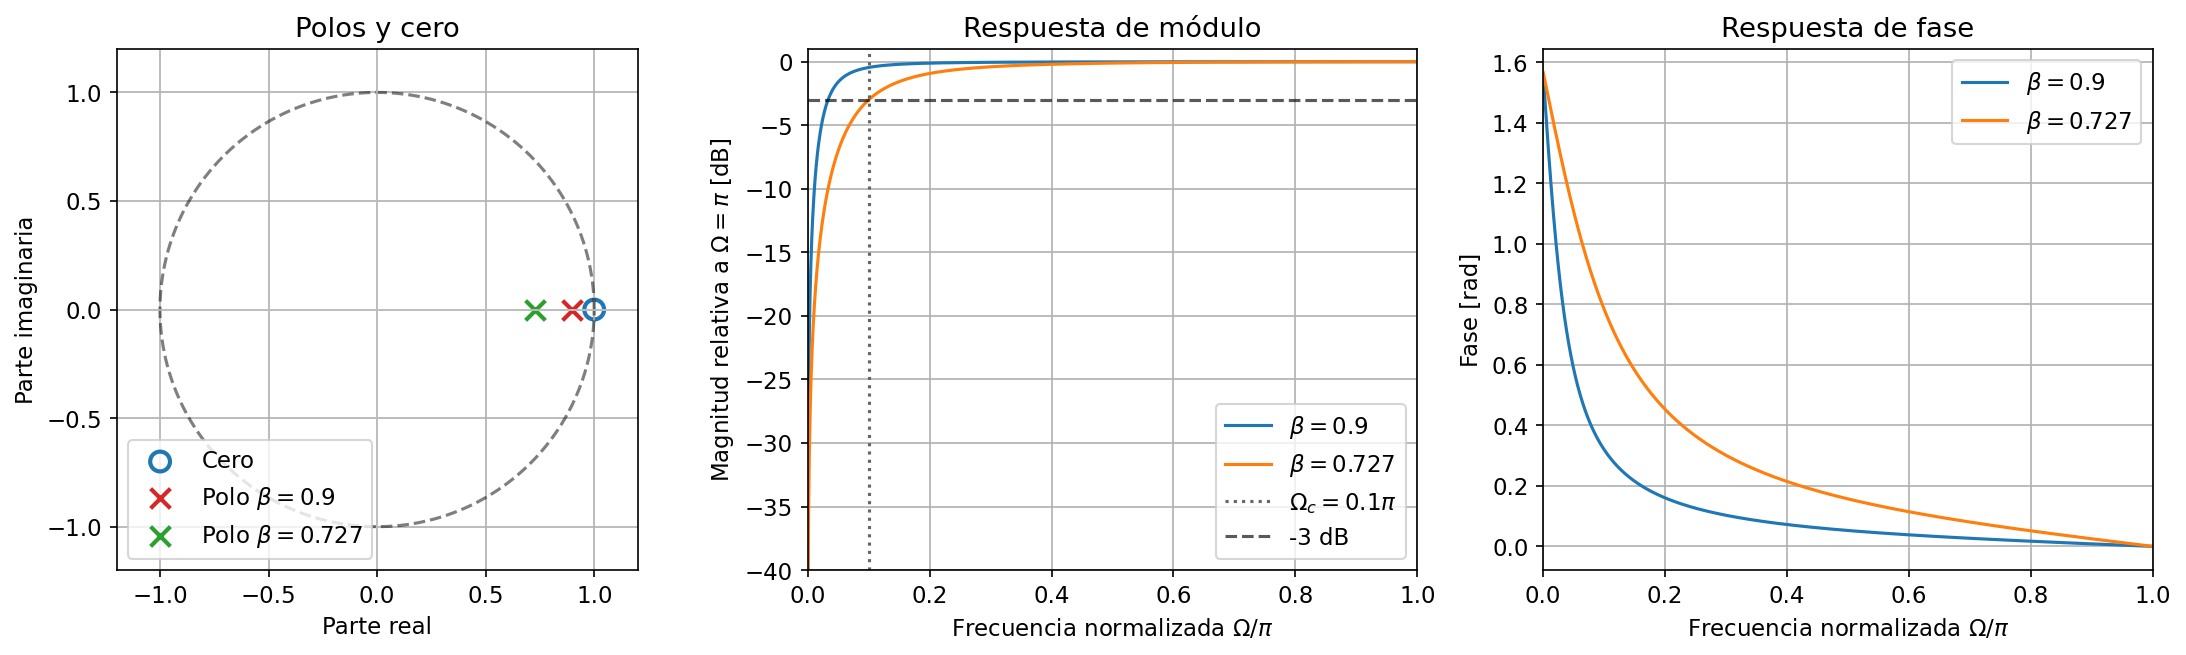

In [13]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

beta_verificacion = 0.9
omega_c = 0.1 * np.pi
beta_3db = (1 - np.sin(omega_c)) / np.cos(omega_c)

omega_dc = np.linspace(0, np.pi, 2049)


def respuesta_dc(beta, frecuencias):
    numerador_dc = np.array([1.0, -1.0])
    denominador_dc = np.array([1.0, -beta])
    _, respuesta = sig.freqz(numerador_dc, denominador_dc, worN=frecuencias)
    respuesta_cerrada = (
        (1 - np.exp(-1j * frecuencias))
        / (1 - beta * np.exp(-1j * frecuencias))
    )
    np.testing.assert_allclose(respuesta, respuesta_cerrada, atol=1e-12)
    return respuesta


respuesta_beta_09 = respuesta_dc(beta_verificacion, omega_dc)
respuesta_beta_3db = respuesta_dc(beta_3db, omega_dc)

_, respuesta_puntos = sig.freqz(
    [1.0, -1.0],
    [1.0, -beta_3db],
    worN=np.array([omega_c, np.pi]),
)
relacion_db = 20 * np.log10(abs(respuesta_puntos[0] / respuesta_puntos[1]))
np.testing.assert_allclose(relacion_db, -10 * np.log10(2), atol=1e-12)

print(f'Beta de verificación = {beta_verificacion:.6f}')
print(f'Polo digital = {beta_verificacion:.6f}')
print(f'Beta estable para la condición de 3 dB = {beta_3db:.6f}')
print(f'Relación |H(0.1 pi)| / |H(pi)| = {relacion_db:.6f} dB')

figura_dc, ejes_dc = plt.subplots(1, 3, figsize=(15, 4.5))

angulo_unitario = np.linspace(0, 2 * np.pi, 400)
ejes_dc[0].plot(np.cos(angulo_unitario), np.sin(angulo_unitario), 'k--', alpha=0.5)
ejes_dc[0].scatter(1, 0, s=90, facecolors='none', edgecolors='C0', linewidths=2, label='Cero')
ejes_dc[0].scatter(beta_verificacion, 0, s=90, marker='x', color='C3', linewidths=2, label=r'Polo $\beta=0.9$')
ejes_dc[0].scatter(beta_3db, 0, s=90, marker='x', color='C2', linewidths=2, label=fr'Polo $\beta={beta_3db:.3f}$')
ejes_dc[0].axhline(0, color='0.75', linewidth=0.8)
ejes_dc[0].axvline(0, color='0.75', linewidth=0.8)
ejes_dc[0].set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), xlabel='Parte real', ylabel='Parte imaginaria', title='Polos y cero')
ejes_dc[0].set_aspect('equal', adjustable='box')
ejes_dc[0].grid(True)
ejes_dc[0].legend(loc='lower left')

for respuesta, etiqueta in (
    (respuesta_beta_09, r'$\beta=0.9$'),
    (respuesta_beta_3db, fr'$\beta={beta_3db:.3f}$'),
):
    magnitud_relativa = np.abs(respuesta) / np.abs(respuesta[-1])
    magnitud_relativa_db = 20 * np.log10(np.maximum(magnitud_relativa, 1e-12))
    ejes_dc[1].plot(omega_dc / np.pi, magnitud_relativa_db, label=etiqueta)

ejes_dc[1].axvline(omega_c / np.pi, color='0.4', linestyle=':', label=r'$\Omega_c=0.1\pi$')
ejes_dc[1].axhline(-10 * np.log10(2), color='k', linestyle='--', alpha=0.65, label='-3 dB')
ejes_dc[1].set(xlim=(0, 1), ylim=(-40, 1), xlabel=r'Frecuencia normalizada $\Omega/\pi$', ylabel=r'Magnitud relativa a $\Omega=\pi$ [dB]', title='Respuesta de módulo')
ejes_dc[1].grid(True)
ejes_dc[1].legend()

for respuesta, etiqueta in (
    (respuesta_beta_09, r'$\beta=0.9$'),
    (respuesta_beta_3db, fr'$\beta={beta_3db:.3f}$'),
):
    mascara_fase = np.abs(respuesta) > 1e-10
    ejes_dc[2].plot(omega_dc[mascara_fase] / np.pi, np.angle(respuesta[mascara_fase]), label=etiqueta)

ejes_dc[2].set(xlim=(0, 1), xlabel=r'Frecuencia normalizada $\Omega/\pi$', ylabel='Fase [rad]', title='Respuesta de fase')
ejes_dc[2].grid(True)
ejes_dc[2].legend()

figura_dc.tight_layout()
plt.show()

<a id="p5"></a>

***

## Punto 5 — Filtro Peine

Filtro **Peine** ( Comb filter )

* Verifique la transferencia para $c_1 = -1$ y $N = 8$
* Proponga una $f_{sampling}$ y halle las frecuencias donde se generan los peaks y los nulls en el espectro.

### Resolución analítica: filtro peine

<div>
  <img src="./img/punto_5_1.jpg" width="500" />
</div>
<div>
  <img src="./img/punto_5_2.jpg" width="500" />
</div>


#### A. Transferencia y ecuación en diferencias

Se toma $c_1=-1$ y $N=8$. Para que la red biquad sea un pasaje directo se eligen

$$
a_0=1,\qquad b_0=1,
$$

con $a_1=a_2=b_1=b_2=0$. Al sustituir en la transferencia general:

$$
\begin{aligned}
H_P(z)
&=(1-c_1z^{-N})\frac{b_0}{1/a_0}\\
&=1-(-1)z^{-8},
\end{aligned}
$$

por lo que

$$
\boxed{H_P(z)=1+z^{-8}}.
$$

La ecuación en diferencias es

$$
\boxed{y[n]=x[n]+x[n-8]}.
$$

El diagrama en bloques divide la entrada en una rama directa y otra con ocho retardos; ambas se suman con signo positivo.

#### B. Polos y ceros

En potencias positivas de $z$:

$$
H_P(z)=\frac{z^8+1}{z^8}.
$$

Los ceros satisfacen

$$
z^8+1=0
\quad\Longrightarrow\quad
z^8=-1=e^{j(2k+1)\pi}.
$$

Por lo tanto,

$$
\boxed{z_k=e^{j(2k+1)\pi/8},\qquad k=0,1,\ldots,7}.
$$

Son ocho ceros uniformemente distribuidos sobre la circunferencia unitaria, comenzando en el ángulo $\pi/8$. Además, la forma causal posee ocho polos en el origen, asociados al retardo $z^{-8}$.

#### C. Respuesta de módulo y fase

Sobre la circunferencia unitaria:

$$
H_P(e^{j\Omega})=1+e^{-j8\Omega}.
$$

Factorizando $e^{-j4\Omega}$:

$$
\begin{aligned}
H_P(e^{j\Omega})
&=e^{-j4\Omega}\left(e^{j4\Omega}+e^{-j4\Omega}\right)\\
&=\boxed{2e^{-j4\Omega}\cos(4\Omega)}.
\end{aligned}
$$

Así, el módulo es

$$
\boxed{|H_P(e^{j\Omega})|=2|\cos(4\Omega)|}.
$$

La fase contiene un término lineal de retardo y saltos de $\pi$ cuando el coseno cambia de signo:

$$
\phi_P(\Omega)=
\begin{cases}
-4\Omega, & \cos(4\Omega)>0,\\
-4\Omega+\pi, & \cos(4\Omega)<0,
\end{cases}
\qquad (\operatorname{mod}2\pi).
$$

En los nulls, donde $\cos(4\Omega)=0$, la fase no está definida. Entre nulls, el retardo de grupo es de cuatro muestras.

#### D. Frecuencias de peaks y nulls

Los peaks aparecen cuando $|\cos(4\Omega)|=1$:

$$
4\Omega=m\pi
\quad\Longrightarrow\quad
\boxed{\Omega_{p,m}=\frac{m\pi}{4}},
$$

mientras que los nulls aparecen cuando $\cos(4\Omega)=0$:

$$
4\Omega=\frac{(2m+1)\pi}{2}
\quad\Longrightarrow\quad
\boxed{\Omega_{z,m}=\frac{(2m+1)\pi}{8}}.
$$

La conversión de frecuencia angular digital a frecuencia física es

$$
f=\frac{\Omega}{2\pi}f_s.
$$

Por lo tanto,

$$
\boxed{f_{p,m}=\frac{m}{8}f_s},
\qquad
\boxed{f_{z,m}=\frac{2m+1}{16}f_s}.
$$

Se propone

$$
f_s=8\,\text{kHz}.
$$

En el espectro unilateral $0\leq f\leq f_s/2$ se obtiene:

| Tipo | Índices | Frecuencias |
|:---|:---:|:---|
| Peaks, $\lvert H\rvert=2$ | $m=0,1,2,3,4$ | $0,\ 1,\ 2,\ 3,\ 4\ \text{kHz}$ |
| Nulls, $\lvert H\rvert=0$ | $m=0,1,2,3$ | $0.5,\ 1.5,\ 2.5,\ 3.5\ \text{kHz}$ |

El patrón se repite periódicamente cada $f_s$.

Frecuencia de muestreo propuesta: 8.0 kHz
Peaks [Hz]: [   0 1000 2000 3000 4000]
Nulls [Hz]: [ 500 1500 2500 3500]


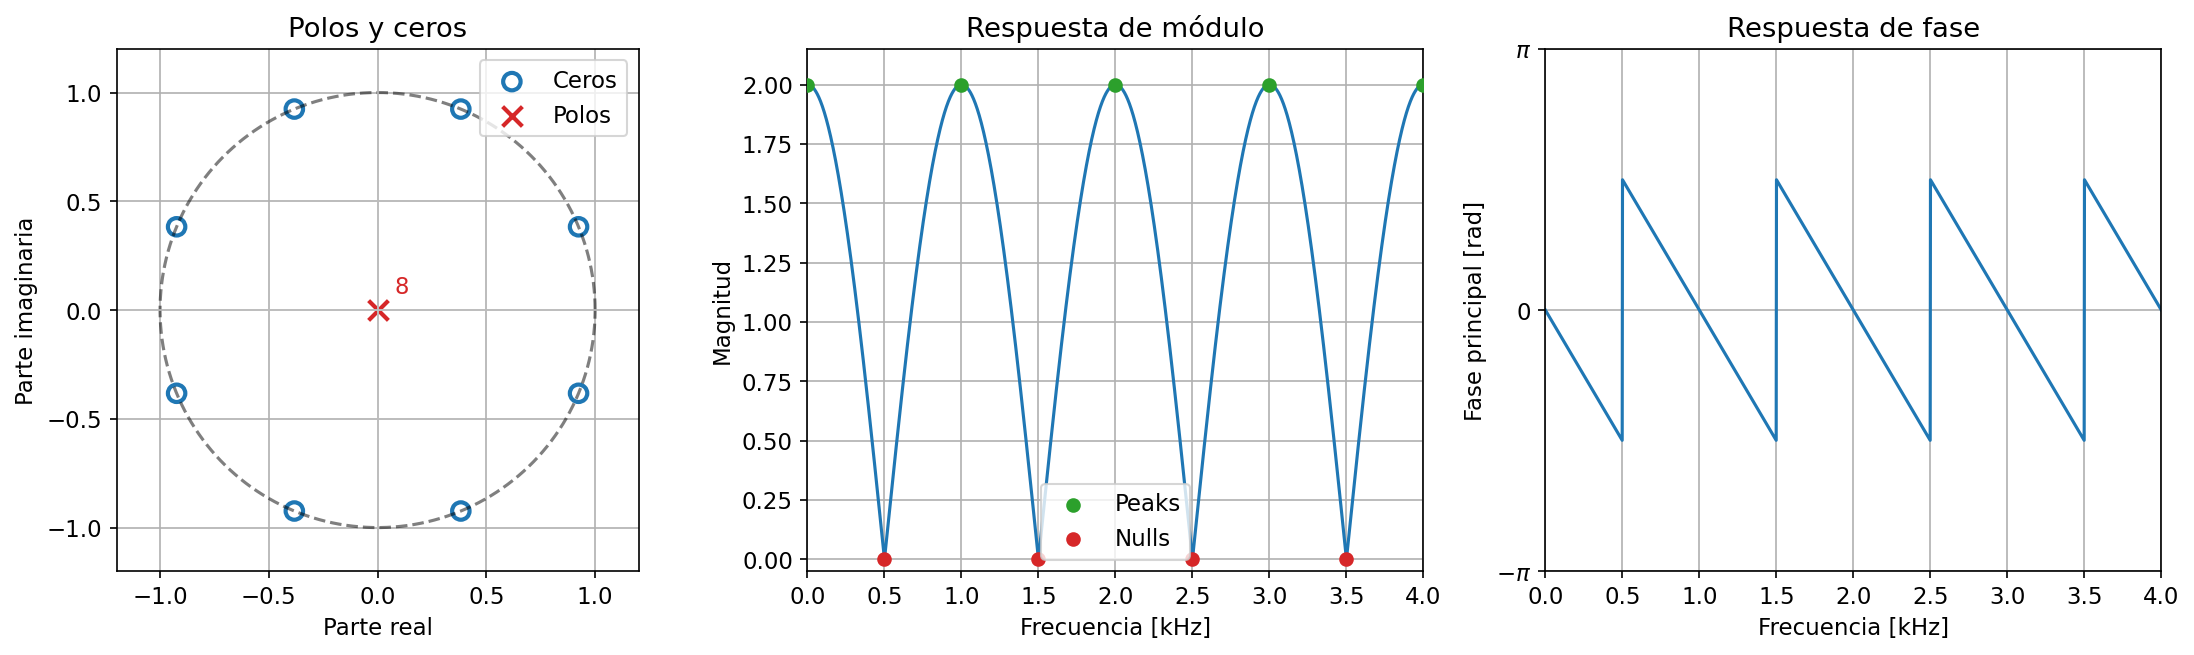

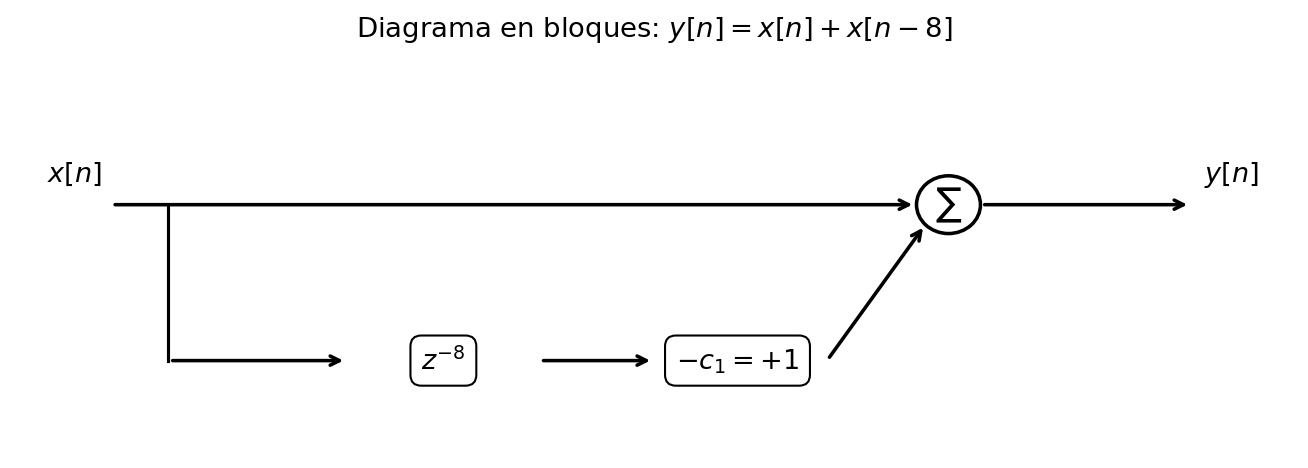

In [14]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

retardo_peine = 8
frecuencia_muestreo = 8_000.0  # Hz
coeficientes_peine = np.r_[1.0, np.zeros(retardo_peine - 1), 1.0]
denominador_peine = np.array([1.0])

frecuencia_hz = np.linspace(0, frecuencia_muestreo / 2, 4097)
omega_peine = 2 * np.pi * frecuencia_hz / frecuencia_muestreo
_, respuesta_peine = sig.freqz(
    coeficientes_peine,
    denominador_peine,
    worN=omega_peine,
)
respuesta_peine_analitica = (
    2 * np.exp(-1j * retardo_peine * omega_peine / 2)
    * np.cos(retardo_peine * omega_peine / 2)
)
np.testing.assert_allclose(respuesta_peine, respuesta_peine_analitica, atol=1e-12)

indices_peaks = np.arange(retardo_peine // 2 + 1)
indices_nulls = np.arange(retardo_peine // 2)
frecuencias_peaks = indices_peaks * frecuencia_muestreo / retardo_peine
frecuencias_nulls = (2 * indices_nulls + 1) * frecuencia_muestreo / (2 * retardo_peine)

omega_peaks = 2 * np.pi * frecuencias_peaks / frecuencia_muestreo
omega_nulls = 2 * np.pi * frecuencias_nulls / frecuencia_muestreo
_, respuesta_peaks = sig.freqz(coeficientes_peine, denominador_peine, worN=omega_peaks)
_, respuesta_nulls = sig.freqz(coeficientes_peine, denominador_peine, worN=omega_nulls)
np.testing.assert_allclose(np.abs(respuesta_peaks), 2.0, atol=1e-12)
np.testing.assert_allclose(np.abs(respuesta_nulls), 0.0, atol=1e-12)

ceros_peine = np.roots(coeficientes_peine)
polos_peine = np.zeros(retardo_peine)
np.testing.assert_allclose(np.abs(ceros_peine), 1.0, atol=1e-12)

print(f'Frecuencia de muestreo propuesta: {frecuencia_muestreo / 1000:.1f} kHz')
print('Peaks [Hz]:', frecuencias_peaks.astype(int))
print('Nulls [Hz]:', frecuencias_nulls.astype(int))

figura_peine, ejes_peine = plt.subplots(1, 3, figsize=(15, 4.5))

angulo_unitario = np.linspace(0, 2 * np.pi, 400)
ejes_peine[0].plot(np.cos(angulo_unitario), np.sin(angulo_unitario), 'k--', alpha=0.5)
ejes_peine[0].scatter(
    ceros_peine.real,
    ceros_peine.imag,
    s=70,
    facecolors='none',
    edgecolors='C0',
    linewidths=2,
    label='Ceros',
)
ejes_peine[0].scatter(0, 0, s=90, marker='x', color='C3', linewidths=2, label='Polos')
ejes_peine[0].annotate('8', (0, 0), xytext=(8, 8), textcoords='offset points', color='C3')
ejes_peine[0].axhline(0, color='0.75', linewidth=0.8)
ejes_peine[0].axvline(0, color='0.75', linewidth=0.8)
ejes_peine[0].set(xlim=(-1.2, 1.2), ylim=(-1.2, 1.2), xlabel='Parte real', ylabel='Parte imaginaria', title='Polos y ceros')
ejes_peine[0].set_aspect('equal', adjustable='box')
ejes_peine[0].grid(True)
ejes_peine[0].legend(loc='upper right')

ejes_peine[1].plot(frecuencia_hz / 1000, np.abs(respuesta_peine), color='C0')
ejes_peine[1].scatter(frecuencias_peaks / 1000, np.abs(respuesta_peaks), color='C2', zorder=3, label='Peaks')
ejes_peine[1].scatter(frecuencias_nulls / 1000, np.abs(respuesta_nulls), color='C3', zorder=3, label='Nulls')
ejes_peine[1].set(xlim=(0, frecuencia_muestreo / 2000), ylim=(-0.05, 2.15), xlabel='Frecuencia [kHz]', ylabel='Magnitud', title='Respuesta de módulo')
ejes_peine[1].grid(True)
ejes_peine[1].legend()

mascara_fase_peine = np.abs(respuesta_peine) > 1e-8
ejes_peine[2].plot(
    frecuencia_hz[mascara_fase_peine] / 1000,
    np.angle(respuesta_peine[mascara_fase_peine]),
    color='C0',
)
ejes_peine[2].set(xlim=(0, frecuencia_muestreo / 2000), xlabel='Frecuencia [kHz]', ylabel='Fase principal [rad]', title='Respuesta de fase')
ejes_peine[2].set_yticks([-np.pi, 0, np.pi], [r'$-\pi$', '0', r'$\pi$'])
ejes_peine[2].grid(True)

figura_peine.tight_layout()
plt.show()


def dibujar_bloque_peine(eje, centro, texto):
    eje.text(
        centro[0],
        centro[1],
        texto,
        ha='center',
        va='center',
        fontsize=13,
        bbox={'boxstyle': 'round,pad=0.4', 'facecolor': 'white', 'edgecolor': 'black'},
    )


def dibujar_flecha_peine(eje, inicio, fin):
    eje.annotate('', xy=fin, xytext=inicio, arrowprops={'arrowstyle': '->', 'lw': 1.7})


figura_bloques_peine, eje_bloques_peine = plt.subplots(figsize=(11, 3.5))
eje_bloques_peine.set_xlim(0, 10)
eje_bloques_peine.set_ylim(0, 3.5)
eje_bloques_peine.axis('off')

sumador_peine = (7.3, 2.15)
eje_bloques_peine.add_patch(Circle(sumador_peine, 0.25, fill=False, linewidth=1.7))
eje_bloques_peine.text(*sumador_peine, r'$\sum$', ha='center', va='center', fontsize=13)

eje_bloques_peine.text(0.25, 2.35, r'$x[n]$', fontsize=13)
dibujar_flecha_peine(eje_bloques_peine, (0.75, 2.15), (7.05, 2.15))
dibujar_flecha_peine(eje_bloques_peine, (7.55, 2.15), (9.2, 2.15))
eje_bloques_peine.text(9.3, 2.35, r'$y[n]$', fontsize=13)

eje_bloques_peine.plot([1.2, 1.2], [2.15, 0.8], color='black', linewidth=1.5)
dibujar_flecha_peine(eje_bloques_peine, (1.2, 0.8), (2.6, 0.8))
dibujar_bloque_peine(eje_bloques_peine, (3.35, 0.8), r'$z^{-8}$')
dibujar_flecha_peine(eje_bloques_peine, (4.1, 0.8), (5.0, 0.8))
dibujar_bloque_peine(eje_bloques_peine, (5.65, 0.8), r'$-c_1=+1$')
dibujar_flecha_peine(eje_bloques_peine, (6.35, 0.8), (7.12, 1.98))

eje_bloques_peine.set_title(r'Diagrama en bloques: $y[n]=x[n]+x[n-8]$')
plt.show()

<a id="bonus"></a>

## Bonus

* Verificar en Python el punto 3) con la función `diff`
* Utilizando solo el *biquad*, hallar los valores de los coeficientes para emular la respuesta analógica de un pasatodo de orden 1. Utilice alguno de los métodos de diseño vistos en clases.

### Resolución del bonus

#### A. Verificación del diferenciador con `scipy.fftpack.diff`

La función [`scipy.fftpack.diff`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.fftpack.diff.html) calcula la derivada espectral de una secuencia periódica. Si $\widehat{x}_k$ son sus coeficientes de Fourier, para una derivada de primer orden aplica

$$
\widehat{x'_k}
=j\frac{2\pi k}{T}\widehat{x}_k,
$$

donde $T$ es el parámetro `period`.

Para $M$ muestras separadas por un intervalo unitario, la extensión periódica tiene período $T=M$. Por eso debe utilizarse

```python
fftpack.diff(x, order=1, period=M)
```

y no dejar el valor predeterminado `period=2*pi`. Además, se elige una senoide que contiene un número entero de ciclos en el registro para evitar una discontinuidad entre sus extremos.

La derivada espectral se obtiene en la muestra $n$, mientras que el filtro del punto 3 aproxima la derivada en $n-1$. La comparación correcta es entonces

$$
y[n]\quad\text{con}\quad x'_{\mathrm{FFT}}[n-1].
$$

Como la señal usada es periódica, el desplazamiento de una muestra puede implementarse mediante `np.roll`.



Error máximo de fftpack.diff: 3.053e-15
Error de amplitud de la diferencia central: 1.637 %


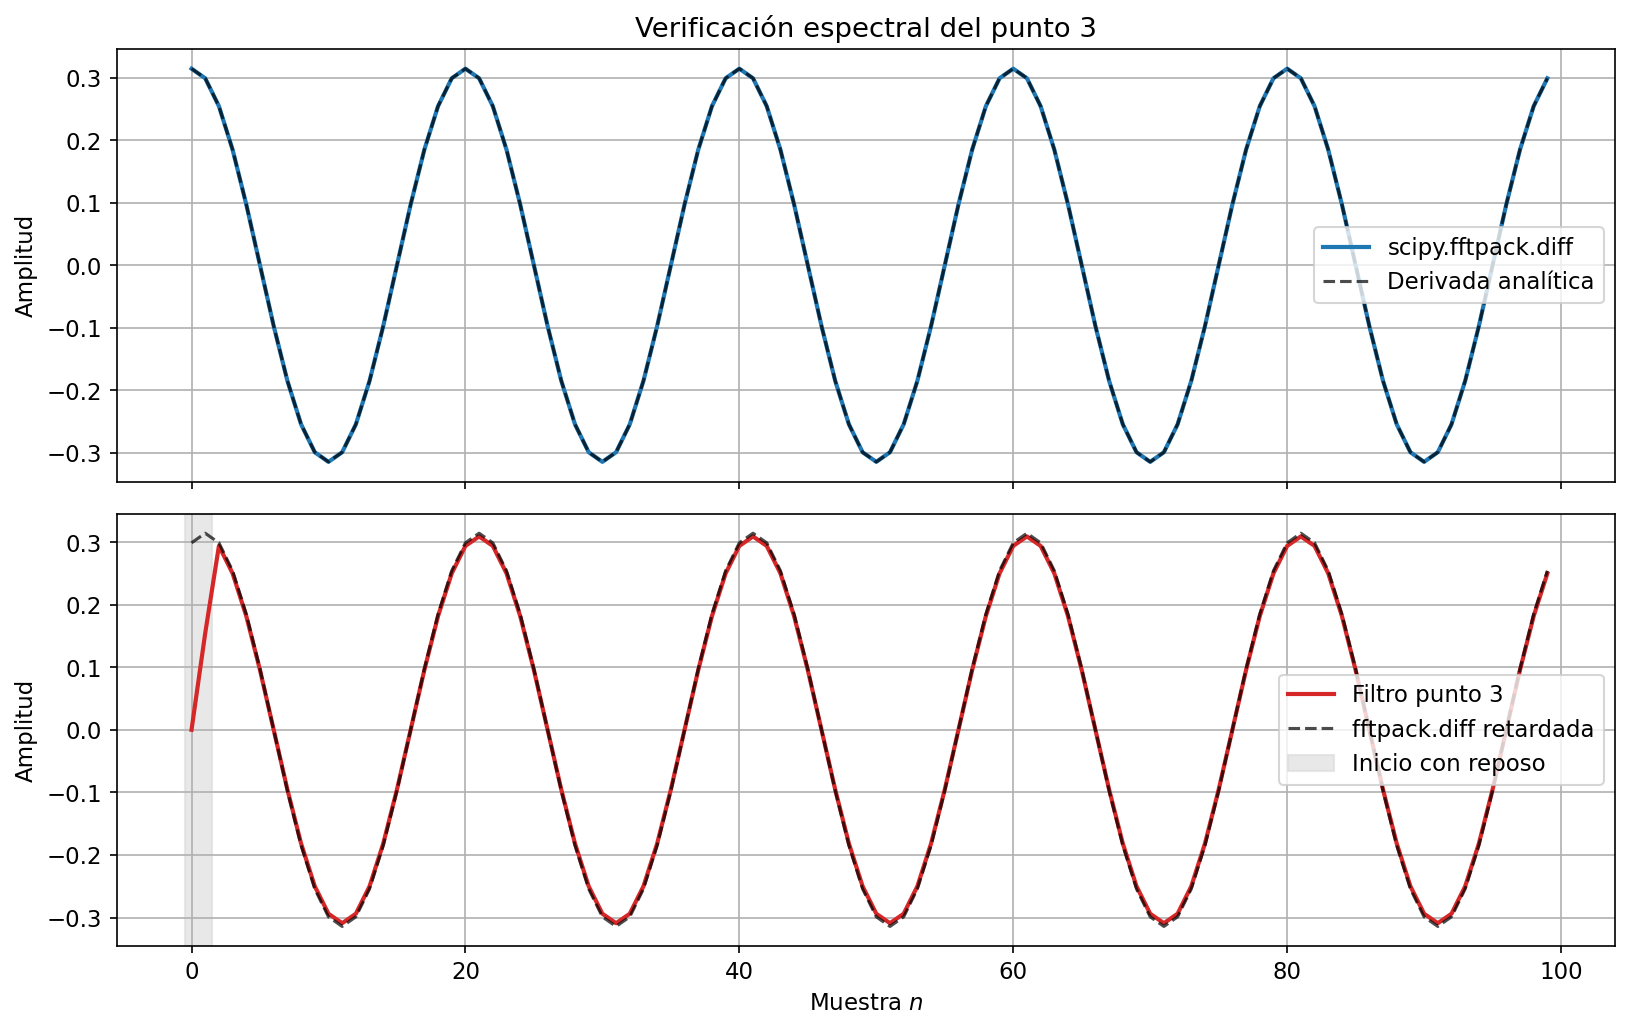

In [18]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.fftpack import diff as derivada_fftpack

# Bonus A: verificación espectral del diferenciador del punto 3.
muestras_fft = 100
indice_fft = np.arange(muestras_fft)
frecuencia_seno = 0.05  # ciclos/muestra
omega_seno = 2 * np.pi * frecuencia_seno
senal_fft = np.sin(omega_seno * indice_fft)

derivada_espectral = derivada_fftpack(
    senal_fft,
    order=1,
    period=muestras_fft,
)
derivada_analitica = omega_seno * np.cos(omega_seno * indice_fft)
np.testing.assert_allclose(derivada_espectral, derivada_analitica, atol=1e-12)

salida_diferencia = sig.lfilter([0.5, 0.0, -0.5], [1.0], senal_fft) # Filtro punto 3
derivada_espectral_retardada = np.roll(derivada_espectral, 1)
mascara_regimen = indice_fft >= 2

error_fft_maximo = np.max(np.abs(derivada_espectral - derivada_analitica))
error_diferencia_relativo = 100 * (
    1 - np.sin(omega_seno) / omega_seno
)

print(f'Error máximo de fftpack.diff: {error_fft_maximo:.3e}')
print(f'Error de amplitud de la diferencia central: {error_diferencia_relativo:.3f} %')

figura_fft, ejes_fft = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ejes_fft[0].plot(indice_fft, derivada_espectral, color='C0', linewidth=2, label='scipy.fftpack.diff')
ejes_fft[0].plot(indice_fft, derivada_analitica, 'k--', alpha=0.7, label='Derivada analítica')
ejes_fft[0].set(title='Verificación espectral del punto 3', ylabel='Amplitud')
ejes_fft[0].grid(True)
ejes_fft[0].legend()

ejes_fft[1].plot(indice_fft, salida_diferencia, color='C3', linewidth=2, label='Filtro punto 3')
ejes_fft[1].plot(indice_fft, derivada_espectral_retardada, 'k--', alpha=0.7, label='fftpack.diff retardada')
ejes_fft[1].axvspan(-0.5, 1.5, color='0.85', alpha=0.6, label='Inicio con reposo')
ejes_fft[1].set(xlabel='Muestra $n$', ylabel='Amplitud')
ejes_fft[1].grid(True)
ejes_fft[1].legend()
figura_fft.tight_layout()
plt.show()


#### B. Pasatodo analógico de primer orden mediante un biquad

#### 0. Resolución manuscrita

<div>
  <img src="./img/bonus_2_1.jpg" width="500" />
</div>
<div>
  <img src="./img/bonus_2_2.jpg" width="500" />
</div>

Se parte del pasatodo analógico estable

$$
\boxed{H_a(s)=\frac{s-\omega_a}{s+\omega_a}}.
$$

Su polo está en $s=-\omega_a$, su cero en $s=+\omega_a$ y su módulo sobre el eje imaginario es unitario:

$$
|H_a(j\omega)|=1.
$$

Se emplea la transformación bilineal

$$
s=\frac{2}{T_s}\frac{1-z^{-1}}{1+z^{-1}}.
$$

Para hacer coincidir exactamente una frecuencia digital elegida $\Omega_0$ se realiza prewarping:

$$
\omega_a=\frac{2}{T_s}\tan\left(\frac{\Omega_0}{2}\right).
$$

Sustituyendo la transformación bilineal en $H_a(s)$ y normalizando el denominador se obtiene

$$
\boxed{H_{AP}(z)=\frac{\alpha-z^{-1}}{1-\alpha z^{-1}}},
$$

con

$$
\boxed{\alpha=\frac{\frac{2}{T_s}-\omega_a}{\frac{2}{T_s}+\omega_a}=\frac{1-\tan(\Omega_0/2)}{1+\tan(\Omega_0/2)}}.
$$

Para implementarlo usando solamente el biquad de la consigna se anula el peine con $c_1=0$ y se eligen

$$
\boxed{
\begin{aligned}
a_0&=1, & a_1&=\alpha, & a_2&=0,\\
b_0&=\alpha, & b_1&=-1, & b_2&=0.
\end{aligned}}
$$

La ecuación en diferencias correspondiente es

$$
\boxed{y[n]=\alpha y[n-1]+\alpha x[n]-x[n-1]}.
$$

Multiplicando por $z$:

$$
H_{AP}(z)=\frac{\alpha z-1}{z-\alpha}.
$$

Por lo tanto, el polo y el cero son

$$
p=\alpha,\qquad z_0=\frac{1}{\alpha}.
$$

Son recíprocos: el polo queda dentro de la circunferencia unitaria si $|\alpha|<1$ y el cero queda fuera. Esta simetría garantiza el módulo unitario, ya que

$$
|\alpha-e^{-j\Omega}|^2
=\alpha^2+1-2\alpha\cos\Omega
=|1-\alpha e^{-j\Omega}|^2.
$$

En consecuencia,

$$
\boxed{|H_{AP}(e^{j\Omega})|=1}.
$$

Como ejemplo se eligen $f_s=8\,\text{kHz}$ y una frecuencia de ajuste $f_0=1\,\text{kHz}$, por lo que $\Omega_0=\pi/4$. El coeficiente resulta

$$
\boxed{\alpha=\sqrt{2}-1\approx0.414214}.
$$

Con el prewarping, la frecuencia analógica usada en el prototipo es

$$
\omega_a=2f_s\tan\left(\frac{\pi}{8}\right)
\approx6627.42\ \text{rad/s}.
$$

La magnitud permanece igual a uno y la fase digital reproduce la fase analógica bajo el mapeo bilineal; en $\Omega_0$ vale $\pi/2$ para la convención de pasatodo elegida.

Alfa del pasatodo = 0.414214
Polo digital = 0.414214
Cero digital = 2.414214
Frecuencia analógica prewarpeada = 6627.417 rad/s
Fase en 1.0 kHz = 1.570796 rad
Desvío máximo de |H| respecto de 1 = 4.441e-16


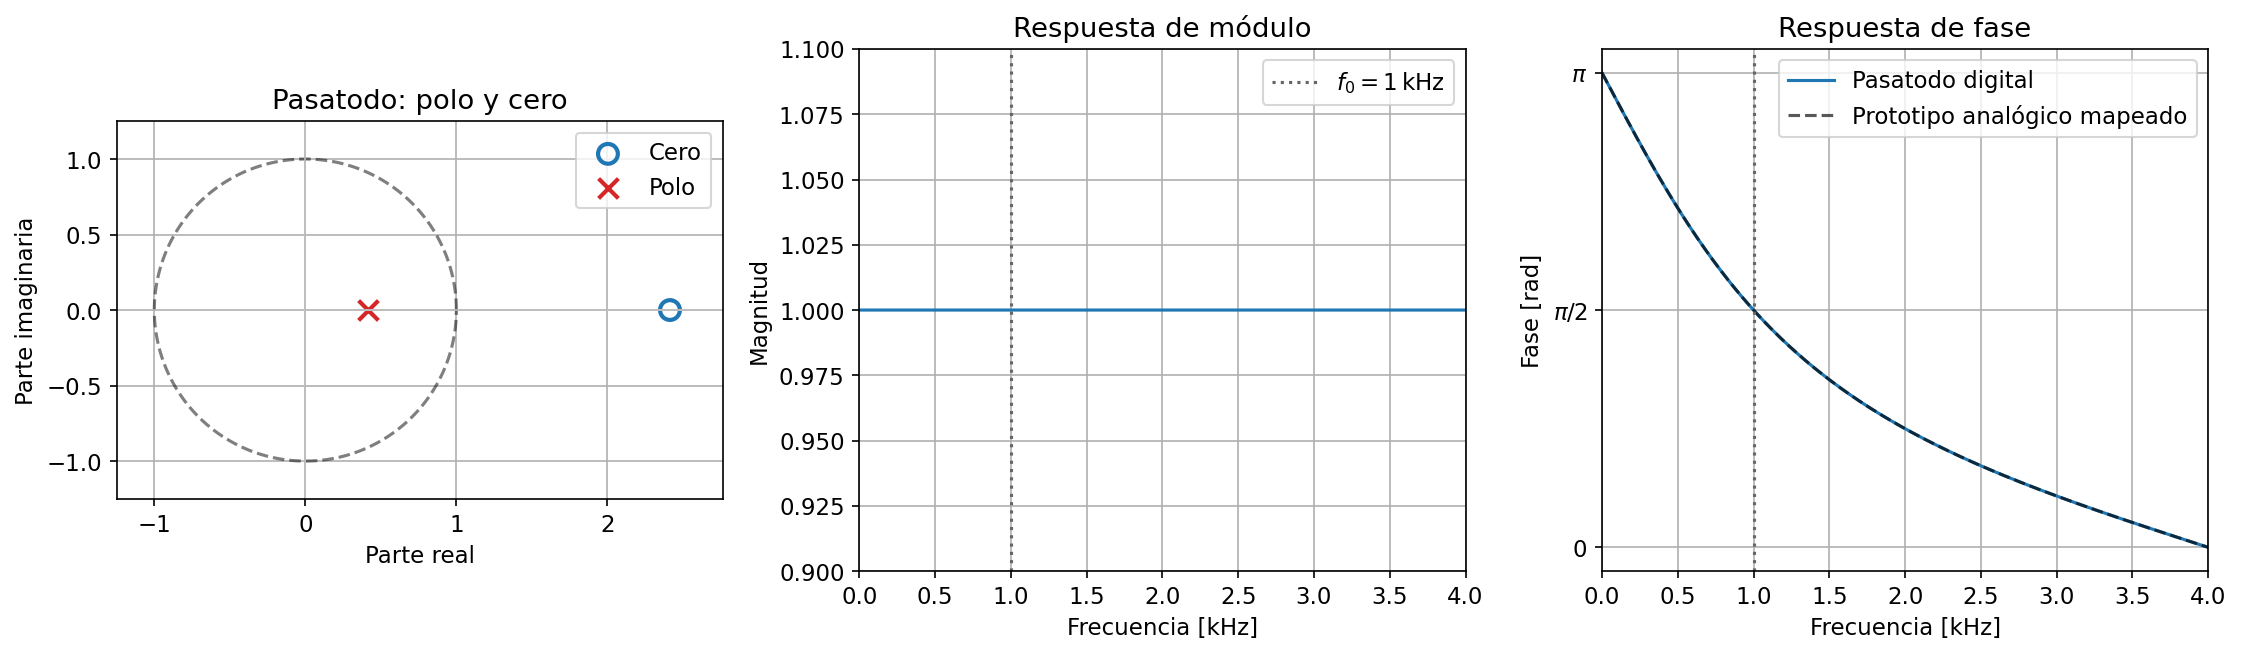

In [16]:
# Bonus B: pasatodo de primer orden mediante transformación bilineal.
frecuencia_muestreo_ap = 8_000.0  # Hz
frecuencia_ajuste_ap = 1_000.0     # Hz
periodo_muestreo_ap = 1 / frecuencia_muestreo_ap
omega_ajuste_ap = 2 * np.pi * frecuencia_ajuste_ap / frecuencia_muestreo_ap
omega_analogica_prewarp = (
    2 / periodo_muestreo_ap * np.tan(omega_ajuste_ap / 2)
)
alfa_ap = (
    2 / periodo_muestreo_ap - omega_analogica_prewarp
) / (
    2 / periodo_muestreo_ap + omega_analogica_prewarp
)

numerador_ap = np.array([alfa_ap, -1.0])
denominador_ap = np.array([1.0, -alfa_ap])
frecuencia_ap_hz = np.linspace(0, frecuencia_muestreo_ap / 2, 2049)
omega_ap = 2 * np.pi * frecuencia_ap_hz / frecuencia_muestreo_ap
_, respuesta_ap = sig.freqz(numerador_ap, denominador_ap, worN=omega_ap)

respuesta_ap_cerrada = (
    alfa_ap - np.exp(-1j * omega_ap)
) / (
    1 - alfa_ap * np.exp(-1j * omega_ap)
)
np.testing.assert_allclose(respuesta_ap, respuesta_ap_cerrada, atol=1e-12)
np.testing.assert_allclose(np.abs(respuesta_ap), 1.0, atol=1e-12)

frecuencia_analogica_equivalente = (
    2 / periodo_muestreo_ap * np.tan(omega_ap / 2)
)
respuesta_analogica_mapeada = (
    1j * frecuencia_analogica_equivalente - omega_analogica_prewarp
) / (
    1j * frecuencia_analogica_equivalente + omega_analogica_prewarp
)
np.testing.assert_allclose(respuesta_ap, respuesta_analogica_mapeada, atol=1e-12)

cero_ap = 1 / alfa_ap
polo_ap = alfa_ap
_, respuesta_ajuste = sig.freqz(
    numerador_ap,
    denominador_ap,
    worN=np.array([omega_ajuste_ap]),
)

print(f'Alfa del pasatodo = {alfa_ap:.6f}')
print(f'Polo digital = {polo_ap:.6f}')
print(f'Cero digital = {cero_ap:.6f}')
print(f'Frecuencia analógica prewarpeada = {omega_analogica_prewarp:.3f} rad/s')
print(f'Fase en {frecuencia_ajuste_ap / 1000:.1f} kHz = {np.angle(respuesta_ajuste[0]):.6f} rad')
print(f'Desvío máximo de |H| respecto de 1 = {np.max(np.abs(np.abs(respuesta_ap) - 1)):.3e}')

figura_ap, ejes_ap = plt.subplots(1, 3, figsize=(15, 4.5))

angulo_unitario = np.linspace(0, 2 * np.pi, 400)
ejes_ap[0].plot(np.cos(angulo_unitario), np.sin(angulo_unitario), 'k--', alpha=0.5)
ejes_ap[0].scatter(cero_ap, 0, s=90, facecolors='none', edgecolors='C0', linewidths=2, label='Cero')
ejes_ap[0].scatter(polo_ap, 0, s=90, marker='x', color='C3', linewidths=2, label='Polo')
ejes_ap[0].axhline(0, color='0.75', linewidth=0.8)
ejes_ap[0].axvline(0, color='0.75', linewidth=0.8)
ejes_ap[0].set(xlim=(-1.25, cero_ap + 0.35), ylim=(-1.25, 1.25), xlabel='Parte real', ylabel='Parte imaginaria', title='Pasatodo: polo y cero')
ejes_ap[0].set_aspect('equal', adjustable='box')
ejes_ap[0].grid(True)
ejes_ap[0].legend()

ejes_ap[1].plot(frecuencia_ap_hz / 1000, np.abs(respuesta_ap), color='C0')
ejes_ap[1].axvline(frecuencia_ajuste_ap / 1000, color='0.4', linestyle=':', label=r'$f_0=1\,\mathrm{kHz}$')
ejes_ap[1].set(xlim=(0, frecuencia_muestreo_ap / 2000), ylim=(0.9, 1.1), xlabel='Frecuencia [kHz]', ylabel='Magnitud', title='Respuesta de módulo')
ejes_ap[1].grid(True)
ejes_ap[1].legend()

ejes_ap[2].plot(frecuencia_ap_hz / 1000, np.angle(respuesta_ap), color='C0', label='Pasatodo digital')
ejes_ap[2].plot(frecuencia_ap_hz / 1000, np.angle(respuesta_analogica_mapeada), 'k--', alpha=0.65, label='Prototipo analógico mapeado')
ejes_ap[2].axvline(frecuencia_ajuste_ap / 1000, color='0.4', linestyle=':')
ejes_ap[2].set(xlim=(0, frecuencia_muestreo_ap / 2000), xlabel='Frecuencia [kHz]', ylabel='Fase [rad]', title='Respuesta de fase')
ejes_ap[2].set_yticks([0, np.pi / 2, np.pi], ['0', r'$\pi/2$', r'$\pi$'])
ejes_ap[2].grid(True)
ejes_ap[2].legend()

figura_ap.tight_layout()
plt.show()